#Code to load the datasets

In [ ]:
# -------------------------------------------------------------------------
# Dataset download and local setup
# -------------------------------------------------------------------------
# Purpose:
#   Download the official project datasets from the shared Google Drive folder
#   into the Colab runtime.
#
# Why this is needed:
#   The project instructions require using the fixed train/validation/test
#   splits provided by the instructors. Downloading the whole folder here makes
#   the notebook self-contained and reproducible: anyone running it on Colab can
#   obtain the same files before starting the analysis.
#
# Important project-related note:
#   This cell only retrieves data. It does not generate extra examples, alter
#   the splits, or evaluate expressions, so it is compliant with the practical
#   track constraints.
# -------------------------------------------------------------------------

# Data setup: download datasets from shared Google Drive

!pip -q install gdown

import os
from pathlib import Path

DATA_DIR = Path("/content/ML_Exam_Project")
DATA_DIR.mkdir(exist_ok=True)

FOLDER_URL = "https://drive.google.com/drive/folders/1f8t9t6jLE6vFpnu7A-xQuhieDlhk48Iw?usp=share_link"

!gdown --folder "$FOLDER_URL" -O "$DATA_DIR"

Retrieving folder contents
Processing file 1uSTcAolrashExIz6RzS7xMTdiZY7xsxF test_id.jsonl
Processing file 1-y5suAJGJK-OgY7yNm9LkiWnFmCV0zj7 test_long.jsonl
Processing file 1Gr1newDY91vYEQjdyzshR5LYSU_VqT17 test_ood.jsonl
Processing file 184ksDE_EtHRYNt2FaP4Qvhw85OA1AAR4 train.jsonl
Processing file 1nRoACGPmX7BT9vlG_65aenEiXDJmNlwj validation.jsonl
Retrieving folder contents completed
Building directory structure
Building directory structure completed
Downloading...
From: https://drive.google.com/uc?id=1uSTcAolrashExIz6RzS7xMTdiZY7xsxF
To: /content/ML_Exam_Project/test_id.jsonl
100% 222k/222k [00:00<00:00, 110MB/s]
Downloading...
From: https://drive.google.com/uc?id=1-y5suAJGJK-OgY7yNm9LkiWnFmCV0zj7
To: /content/ML_Exam_Project/test_long.jsonl
100% 182k/182k [00:00<00:00, 113MB/s]
Downloading...
From: https://drive.google.com/uc?id=1Gr1newDY91vYEQjdyzshR5LYSU_VqT17
To: /content/ML_Exam_Project/test_ood.jsonl
100% 230k/230k [00:00<00:00, 118MB/s]
Downloading...
From: https://drive.googl

In [ ]:
# -------------------------------------------------------------------------
# File-existence check
# -------------------------------------------------------------------------
# Purpose:
#   Verify that all expected JSONL files are present after the download.
#
# Why this is needed:
#   Many later cells assume that each split exists and has the official name.
#   Failing early with a clear error message is better than discovering missing
#   data much later during model training or evaluation.
#
# Splits checked:
#   - train: used for learning model parameters
#   - validation: used for model selection/hyperparameter tuning
#   - test_id: in-distribution test set
#   - test_ood: out-of-distribution test set
#   - test_long: long-sequence test set required by the Full Practical Track
# -------------------------------------------------------------------------

# Check

from pathlib import Path

DATA_DIR = Path("/content/ML_Exam_Project")

expected_files = [
    "train.jsonl",
    "validation.jsonl",
    "test_id.jsonl",
    "test_ood.jsonl",
    "test_long.jsonl",
]

for filename in expected_files:
    path = DATA_DIR / filename
    assert path.exists(), f"Missing file: {path}"

print("All dataset files found:")
for filename in expected_files:
    print(" -", DATA_DIR / filename)

All dataset files found:
 - /content/ML_Exam_Project/train.jsonl
 - /content/ML_Exam_Project/validation.jsonl
 - /content/ML_Exam_Project/test_id.jsonl
 - /content/ML_Exam_Project/test_ood.jsonl
 - /content/ML_Exam_Project/test_long.jsonl


In [ ]:
# -------------------------------------------------------------------------
# JSONL loading utility
# -------------------------------------------------------------------------
# Purpose:
#   Define a small helper function to load JSON Lines files into pandas
#   DataFrames.
#
# Why JSONL matters here:
#   In the official dataset, each line is an independent JSON object containing
#   one arithmetic expression and its metadata. Reading line-by-line is the
#   natural and memory-safe way to load this format.
#
# Output:
#   A pandas DataFrame with one row per example and columns such as:
#   id, expression, value, length, operator_count, and depth.
# -------------------------------------------------------------------------

import json
import pandas as pd

def load_jsonl(path):
    records = []
    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            records.append(json.loads(line))
    return pd.DataFrame(records)

In [ ]:
# -------------------------------------------------------------------------
# Load all official dataset splits
# -------------------------------------------------------------------------
# Purpose:
#   Load train, validation, ID test, OOD test, and long-sequence test into
#   separate DataFrames.
#
# Why this is important:
#   The project explicitly requires using the official splits. Keeping them
#   separate avoids accidental leakage from validation/test into training and
#   makes later comparisons across distributions easier.
#
# The printed shapes provide a quick sanity check on the number of examples in
# each split before any analysis or modeling.
# -------------------------------------------------------------------------

# Load the datasets

train_df = load_jsonl(DATA_DIR / "train.jsonl")
validation_df = load_jsonl(DATA_DIR / "validation.jsonl")
test_id_df = load_jsonl(DATA_DIR / "test_id.jsonl")
test_ood_df = load_jsonl(DATA_DIR / "test_ood.jsonl")
test_long_df = load_jsonl(DATA_DIR / "test_long.jsonl")

print("Train:", train_df.shape)
print("Validation:", validation_df.shape)
print("Test ID:", test_id_df.shape)
print("Test OOD:", test_ood_df.shape)
print("Test long:", test_long_df.shape)

train_df.head()

Train: (12000, 6)
Validation: (2000, 6)
Test ID: (2000, 6)
Test OOD: (2000, 6)
Test long: (1500, 6)


,id,expression,value,length,operator_count,depth
0,train-00000,4+4+7+3+8-1,25,11,5,5
1,train-00001,5-(6-5)+8+8,20,11,4,5
2,train-00002,5-3+1,3,5,2,3
3,train-00003,1-(1+5+8+7+1),-21,13,5,6
4,train-00004,7+1-(6+5+9),-12,11,4,4


Data analysis setup

In [ ]:
# -------------------------------------------------------------------------
# Common analysis setup
# -------------------------------------------------------------------------
# Purpose:
#   Import the libraries used throughout the EDA - exploratory data analysis and build a dictionary that
#   maps split names to their corresponding DataFrames.
#
# Why we use a dictionary:
#   Most checks and plots must be repeated for every split. A dictionary makes
#   this systematic and reduces copy-paste errors.
#
# Why display settings are adjusted:
#   The EDA produces wide summary tables. Increasing pandas display limits makes
#   those tables easier to inspect inside the notebook.
# -------------------------------------------------------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
from collections import Counter
from pathlib import Path

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)

splits = {
    "train": train_df,
    "validation": validation_df,
    "test_id": test_id_df,
    "test_ood": test_ood_df,
    "test_long": test_long_df,
}

for name, df in splits.items():
    print(f"{name}: {df.shape}")

train: (12000, 6)
validation: (2000, 6)
test_id: (2000, 6)
test_ood: (2000, 6)
test_long: (1500, 6)


Basic checks

In [ ]:
# -------------------------------------------------------------------------
# Basic integrity checks
# -------------------------------------------------------------------------
# Purpose:
#   Verify that every split follows the expected dataset format and does not
#   contain obvious string-level issues.
#
# Checks performed:
#   1. Required columns are present.
#   2. Expressions do not contain whitespace.
#   3. Expressions use only the allowed alphabet: digits, '+', '-', '(' and ')'.
#   4. Expressions and ids are not duplicated within each split.
#
# Why this matters:
#   These checks protect the modeling pipeline. For example, invalid characters
#   would break a character-level tokenizer, while duplicated examples could
#   distort performance estimates.
#
# Project constraint:
#   These checks only inspect strings and metadata. They do not evaluate the
#   expressions and therefore do not implement a symbolic calculator.
# -------------------------------------------------------------------------

REQUIRED_COLUMNS = ["id", "expression", "value", "length", "operator_count", "depth"]
ALLOWED_CHARS = set("0123456789+-()")

def check_required_columns(df, split_name):
    missing = [col for col in REQUIRED_COLUMNS if col not in df.columns]

    if missing:
        print(f"[{split_name}] Missing columns: {missing}")
    else:
        print(f"[{split_name}] All required columns are present.")


def check_for_whitespace(df, split_name, n_examples=5):
    mask = df["expression"].astype(str).str.contains(r"\s", regex=True)
    count = mask.sum()

    print(f"[{split_name}] Expressions containing whitespace: {count}")

    if count > 0:
        display(df.loc[mask, ["id", "expression"]].head(n_examples))


def find_invalid_chars(expression):
    expression = str(expression)
    chars_no_space = set(re.sub(r"\s+", "", expression))
    invalid = chars_no_space - ALLOWED_CHARS
    return "".join(sorted(invalid))


def check_invalid_characters(df, split_name, n_examples=5):
    invalid_chars = df["expression"].apply(find_invalid_chars)
    mask = invalid_chars.str.len() > 0
    count = mask.sum()

    print(f"[{split_name}] Expressions containing invalid characters: {count}")

    if count > 0:
        tmp = df.loc[mask, ["id", "expression"]].copy()
        tmp["invalid_chars"] = invalid_chars[mask]
        display(tmp.head(n_examples))


def run_basic_checks(splits):
    for name, df in splits.items():
        print("=" * 70)
        print(f"Split: {name}")

        check_required_columns(df, name)
        check_for_whitespace(df, name)
        check_invalid_characters(df, name)

        print(f"[{name}] Duplicated expressions: {df['expression'].duplicated().sum()}")
        print(f"[{name}] Duplicated ids: {df['id'].duplicated().sum()}")
        print()


run_basic_checks(splits)

Split: train
[train] All required columns are present.
[train] Expressions containing whitespace: 0
[train] Expressions containing invalid characters: 0
[train] Duplicated expressions: 913
[train] Duplicated ids: 0

Split: validation
[validation] All required columns are present.
[validation] Expressions containing whitespace: 0
[validation] Expressions containing invalid characters: 0
[validation] Duplicated expressions: 34
[validation] Duplicated ids: 0

Split: test_id
[test_id] All required columns are present.
[test_id] Expressions containing whitespace: 0
[test_id] Expressions containing invalid characters: 0
[test_id] Duplicated expressions: 32
[test_id] Duplicated ids: 0

Split: test_ood
[test_ood] All required columns are present.
[test_ood] Expressions containing whitespace: 0
[test_ood] Expressions containing invalid characters: 0
[test_ood] Duplicated expressions: 3
[test_ood] Duplicated ids: 0

Split: test_long
[test_long] All required columns are present.
[test_long] Expre

Feature engineering for data analysis

In [ ]:
# -------------------------------------------------------------------------
# Feature engineering for EDA only
# -------------------------------------------------------------------------
# Purpose:
#   Add descriptive features that help us understand the dataset and later
#   analyze model errors.
#
# Important compliance note:
#   This code DOES NOT evaluate arithmetic expressions. It only counts
#   characters, operators, parentheses, and basic string properties. This is
#   allowed preprocessing/analysis, not symbolic evaluation.
#
# Main features added:
#   - computed_length: actual string length, used to verify metadata
#   - digit_count, plus_count, binary_minus_count: token/operator statistics
#   - paren_count and computed_depth: parenthesis-structure indicators
#   - subtraction_ratio: fraction of operators that are '-'
#   - abs_value: target magnitude, useful for error analysis
#   - target_class: maps integer values [-99, 99] to class indices [0, 198]
#
# Why we add target_class:
#   If the final models are formulated as classifiers, the target value must be
#   converted to a non-negative class index. This mapping is reversible:
#     predicted_value = predicted_class - 99
#
# Metadata consistency:
#   The final boolean columns check whether the official metadata agrees with
#   quantities recomputed from the expression string.
# -------------------------------------------------------------------------

#This does NOT evaluate expressions

def parenthesis_info(expression):
    """
    Computes simple information about parentheses.
    It does not evaluate the arithmetic expression.
    """
    expression = str(expression)

    depth = 0
    max_depth = 0
    min_depth = 0

    for ch in expression:
        if ch == "(":
            depth += 1
            max_depth = max(max_depth, depth)
        elif ch == ")":
            depth -= 1
            min_depth = min(min_depth, depth)

    return {
        "computed_depth": max_depth,
        "parentheses_balanced": depth == 0 and min_depth >= 0,
    }


def count_unary_minus(expression):
    """
    Counts minus signs that appear in unary position.

    In the official dataset, operators are binary.
    This function is still useful as a safety check and for possible
    augmented examples.
    """
    expression = re.sub(r"\s+", "", str(expression))
    count = 0

    for i, ch in enumerate(expression):
        if ch == "-":
            if i == 0 or expression[i - 1] in "(+-":
                count += 1

    return count


def add_analysis_features(df):
    df = df.copy()
    df["expression"] = df["expression"].astype(str)

    # String-level features
    df["computed_length"] = df["expression"].str.len()
    df["contains_whitespace"] = df["expression"].str.contains(r"\s", regex=True)

    # Character counts
    df["digit_count"] = df["expression"].str.count(r"\d")
    df["plus_count"] = df["expression"].str.count(r"\+")
    df["minus_count_raw"] = df["expression"].str.count(r"-")
    df["open_paren_count"] = df["expression"].str.count(r"\(")
    df["close_paren_count"] = df["expression"].str.count(r"\)")
    df["paren_count"] = df["open_paren_count"] + df["close_paren_count"]

    # Unary/binary minus distinction
    df["unary_minus_count"] = df["expression"].apply(count_unary_minus)
    df["binary_minus_count"] = df["minus_count_raw"] - df["unary_minus_count"]

    # Estimated number of binary operators
    df["computed_operator_count"] = df["plus_count"] + df["binary_minus_count"]

    # Ratio of subtraction operators among all binary operators
    df["subtraction_ratio"] = (
        df["binary_minus_count"] / df["computed_operator_count"].replace(0, np.nan)
    )
    df["subtraction_ratio"] = df["subtraction_ratio"].fillna(0.0)

    # Parenthesis structure
    par_info = df["expression"].apply(parenthesis_info).apply(pd.Series)
    df = pd.concat([df, par_info], axis=1)

    # Target-related features
    df["abs_value"] = df["value"].abs()

    # Useful for the Transformer classification model
    # value -99 -> class 0
    # value   0 -> class 99
    # value  99 -> class 198
    df["target_class"] = df["value"] + 99

    # Consistency checks
    df["value_in_expected_range"] = df["value"].between(-99, 99)
    df["target_class_in_range"] = df["target_class"].between(0, 198)
    df["length_matches_metadata"] = df["computed_length"].values == df["length"].values
    df["operator_count_matches_metadata"] = df["computed_operator_count"].values == df["operator_count"].values
    df["depth_matches_metadata"] = df["computed_depth"].values == df["depth"].values

    return df


splits = {
    name: add_analysis_features(df)
    for name, df in splits.items()
}

all_data = pd.concat(
    [df.assign(split=name) for name, df in splits.items()],
    ignore_index=True
)

all_data.head()

,id,expression,value,length,operator_count,depth,computed_length,contains_whitespace,digit_count,plus_count,minus_count_raw,open_paren_count,close_paren_count,paren_count,unary_minus_count,binary_minus_count,computed_operator_count,subtraction_ratio,computed_depth,parentheses_balanced,abs_value,target_class,value_in_expected_range,target_class_in_range,length_matches_metadata,operator_count_matches_metadata,depth_matches_metadata,split
0,train-00000,4+4+7+3+8-1,25,11,5,5,11,False,6,4,1,0,0,0,0,1,5,0.20,0,True,25,124,True,True,True,True,False,train
1,train-00001,5-(6-5)+8+8,20,11,4,5,11,False,5,2,2,1,1,2,0,2,4,0.50,1,True,20,119,True,True,True,True,False,train
2,train-00002,5-3+1,3,5,2,3,5,False,3,1,1,0,0,0,0,1,2,0.50,0,True,3,102,True,True,True,True,False,train
3,train-00003,1-(1+5+8+7+1),-21,13,5,6,13,False,6,4,1,1,1,2,0,1,5,0.20,1,True,21,78,True,True,True,True,False,train
4,train-00004,7+1-(6+5+9),-12,11,4,4,11,False,5,3,1,1,1,2,0,1,4,0.25,1,True,12,87,True,True,True,True,False,train


Split summary

In [ ]:
# -------------------------------------------------------------------------
# Compact summary of each split
# -------------------------------------------------------------------------
# Purpose:
#   Build one high-level table describing size, target range, structural
#   complexity, and data-quality checks for each split.
#
# Why this matters for the Full Practical Track:
#   The main goal is generalization under distribution shift. This summary gives
#   a first indication of how train, validation, ID, OOD, and long-sequence data
#   differ in length, depth, operator count, subtraction usage, and target range.
#
# The mismatch counts are especially useful:
#   they tell us whether official metadata can be trusted for later analysis.
# -------------------------------------------------------------------------

def basic_summary(df, split_name):
    return {
        "split": split_name,
        "n_examples": len(df),
        "n_unique_expressions": df["expression"].nunique(),
        "duplicated_expressions": df["expression"].duplicated().sum(),

        "min_value": df["value"].min(),
        "max_value": df["value"].max(),
        "mean_value": df["value"].mean(),
        "mean_abs_value": df["abs_value"].mean(),

        "min_length": df["length"].min(),
        "max_length": df["length"].max(),
        "mean_length": df["length"].mean(),
        "median_length": df["length"].median(),

        "min_operator_count": df["operator_count"].min(),
        "max_operator_count": df["operator_count"].max(),
        "mean_operator_count": df["operator_count"].mean(),

        "min_depth": df["depth"].min(),
        "max_depth": df["depth"].max(),
        "mean_depth": df["depth"].mean(),

        "mean_plus_count": df["plus_count"].mean(),
        "mean_binary_minus_count": df["binary_minus_count"].mean(),
        "mean_subtraction_ratio": df["subtraction_ratio"].mean(),
        "mean_paren_count": df["paren_count"].mean(),

        "whitespace_count": df["contains_whitespace"].sum(),
        "unbalanced_parentheses_count": (~df["parentheses_balanced"]).sum(),

        "length_mismatch_count": (~df["length_matches_metadata"]).sum(),
        "operator_count_mismatch_count": (~df["operator_count_matches_metadata"]).sum(),
        "depth_mismatch_count": (~df["depth_matches_metadata"]).sum(),

        "target_out_of_range_count": (~df["value_in_expected_range"]).sum(),
    }


summary_df = pd.DataFrame([
    basic_summary(df, name)
    for name, df in splits.items()
])

display(summary_df)

,split,n_examples,n_unique_expressions,duplicated_expressions,min_value,max_value,mean_value,mean_abs_value,min_length,max_length,mean_length,median_length,min_operator_count,max_operator_count,mean_operator_count,min_depth,max_depth,mean_depth,mean_plus_count,mean_binary_minus_count,mean_subtraction_ratio,mean_paren_count,whitespace_count,unbalanced_parentheses_count,length_mismatch_count,operator_count_mismatch_count,depth_mismatch_count,target_out_of_range_count
0,train,12000,11087,913,-36,46,4.860750,9.275083,5,19,9.607,9.0,2,5,3.489917,3,6,3.689917,1.775667,1.714250,0.491078,1.627167,0,0,0,0,12000,0
1,validation,2000,1966,34,-32,47,4.585000,9.233000,5,19,9.604,9.0,2,5,3.497000,3,6,3.679000,1.782000,1.715000,0.486608,1.610000,0,0,0,0,2000,0
2,test_id,2000,1968,32,-29,40,5.232500,9.485500,5,19,9.609,9.0,2,5,3.487000,3,6,3.722000,1.788500,1.698500,0.488567,1.635000,0,0,0,0,2000,0
3,test_ood,2000,1997,3,-38,44,4.855500,10.353500,7,23,12.484,13.0,3,6,4.515500,3,7,4.434500,2.288000,2.227500,0.494317,2.453000,0,0,0,0,2000,0
4,test_long,1500,1500,0,-42,51,4.024667,11.287333,15,27,17.744,17.0,5,7,6.214667,4,8,5.500667,2.845333,3.369333,0.549619,4.314667,0,0,0,0,1500,0


Detailed numeric summary

In [ ]:
# -------------------------------------------------------------------------
# Detailed numeric summaries
# -------------------------------------------------------------------------
# Purpose:
#   Compute descriptive statistics for the most relevant numeric features in
#   every split.
#
# Statistics included:
#   count, mean, standard deviation, min, max, and selected percentiles.
#
# Why percentiles are useful:
#   Mean and max alone can hide distributional differences. Percentiles reveal
#   whether a split has systematically longer, deeper, or more subtraction-heavy
#   expressions, which is central to understanding OOD and long-sequence
#   generalization.
# -------------------------------------------------------------------------

NUMERIC_FEATURES = [
    "length",
    "operator_count",
    "depth",
    "value",
    "abs_value",
    "digit_count",
    "plus_count",
    "binary_minus_count",
    "paren_count",
    "subtraction_ratio",
]

detailed_summaries = []

for name, df in splits.items():
    desc = df[NUMERIC_FEATURES].describe(
        percentiles=[0.25, 0.5, 0.75, 0.90, 0.95]
    ).T

    desc.insert(0, "split", name)
    detailed_summaries.append(desc)

detailed_summary_df = pd.concat(detailed_summaries)

display(detailed_summary_df)

,split,count,mean,std,min,25%,50%,75%,90%,95%,max
length,train,12000.0,9.607000,3.184713,5.0,7.000000,9.000000,13.000000,13.000000,15.000000,19.0
operator_count,train,12000.0,3.489917,1.116319,2.0,2.000000,3.000000,4.000000,5.000000,5.000000,5.0
depth,train,12000.0,3.689917,0.736870,3.0,3.000000,4.000000,4.000000,5.000000,5.000000,6.0
value,train,12000.0,4.860750,10.590745,-36.0,-2.000000,5.000000,12.000000,18.000000,22.000000,46.0
abs_value,train,12000.0,9.275083,7.053963,0.0,4.000000,8.000000,13.000000,19.000000,23.000000,46.0
digit_count,train,12000.0,4.489917,1.116319,3.0,3.000000,4.000000,5.000000,6.000000,6.000000,6.0
plus_count,train,12000.0,1.775667,1.136273,0.0,1.000000,2.000000,2.000000,3.000000,4.000000,5.0
binary_minus_count,train,12000.0,1.714250,1.126219,0.0,1.000000,2.000000,2.000000,3.000000,4.000000,5.0
paren_count,train,12000.0,1.627167,1.548180,0.0,0.000000,2.000000,2.000000,4.000000,4.000000,8.0
subtraction_ratio,train,12000.0,0.491078,0.294828,0.0,0.333333,0.500000,0.666667,1.000000,1.000000,1.0


Overlap between splits

In [ ]:
# -------------------------------------------------------------------------
# Exact expression overlap between splits
# -------------------------------------------------------------------------
# Purpose:
#   Check whether the same expression string appears in more than one split.
#
# Why this matters:
#   If train examples were repeated in validation/test, performance estimates
#   could be artificially optimistic. The project relies on fixed splits, but
#   verifying overlap is still good experimental hygiene.
#
# Interpretation:
#   Ideally, overlap_count should be zero for train-vs-test comparisons.
# -------------------------------------------------------------------------

def overlap_report(splits):
    rows = []
    names = list(splits.keys())

    for i, name_a in enumerate(names):
        expr_a = set(splits[name_a]["expression"])

        for name_b in names[i + 1:]:
            expr_b = set(splits[name_b]["expression"])
            overlap = expr_a.intersection(expr_b)

            rows.append({
                "split_a": name_a,
                "split_b": name_b,
                "overlap_count": len(overlap),
                "overlap_pct_of_a": len(overlap) / len(expr_a) * 100,
                "overlap_pct_of_b": len(overlap) / len(expr_b) * 100,
            })

    return pd.DataFrame(rows)


overlap_df = overlap_report(splits)
display(overlap_df)

,split_a,split_b,overlap_count,overlap_pct_of_a,overlap_pct_of_b
0,train,validation,242,2.182737,12.309257
1,train,test_id,246,2.218815,12.500000
2,train,test_ood,22,0.198431,1.101652
3,train,test_long,0,0.000000,0.000000
4,validation,test_id,67,3.407935,3.404472
5,validation,test_ood,1,0.050865,0.050075
6,validation,test_long,0,0.000000,0.000000
7,test_id,test_ood,1,0.050813,0.050075
8,test_id,test_long,0,0.000000,0.000000
9,test_ood,test_long,0,0.000000,0.000000


Distribution plots

In [ ]:
# -------------------------------------------------------------------------
# Plotting helper functions
# -------------------------------------------------------------------------
# Purpose:
#   Define reusable functions for histograms and boxplots across all splits.
#
# Why histograms:
#   Histograms show the full distribution of a feature, making shifts in length,
#   depth, target magnitude, and subtraction ratio visually clear.
#
# Why boxplots:
#   Boxplots summarize median, interquartile range, and extreme values, allowing
#   quick comparison of distributions across splits.
# -------------------------------------------------------------------------

def plot_hist_by_split(feature, bins=30, density=False):
    plt.figure(figsize=(8, 5))

    for name, df in splits.items():
        plt.hist(
            df[feature].dropna(),
            bins=bins,
            alpha=0.35,
            label=name,
            density=density,
        )

    plt.title(f"Distribution of {feature} by split")
    plt.xlabel(feature)
    plt.ylabel("density" if density else "count")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_box_by_split(feature, showfliers=False):
    labels = []
    values = []

    for name, df in splits.items():
        labels.append(name)
        values.append(df[feature].dropna())

    plt.figure(figsize=(8, 5))
    plt.boxplot(values, labels=labels, showfliers=showfliers)
    plt.title(f"{feature} by split")
    plt.ylabel(feature)
    plt.xticks(rotation=30)
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()

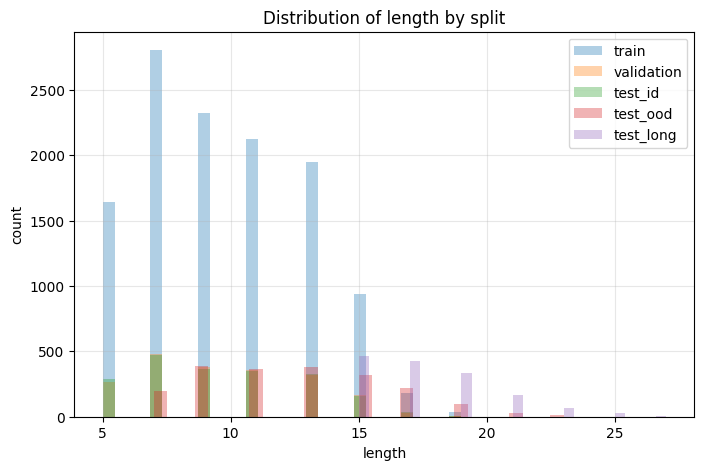

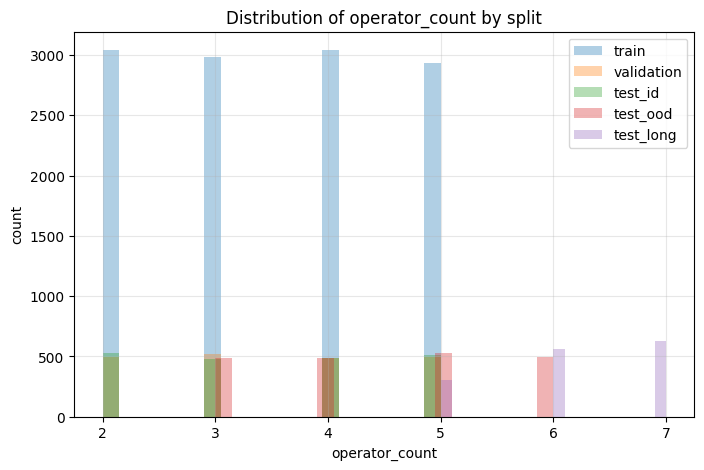

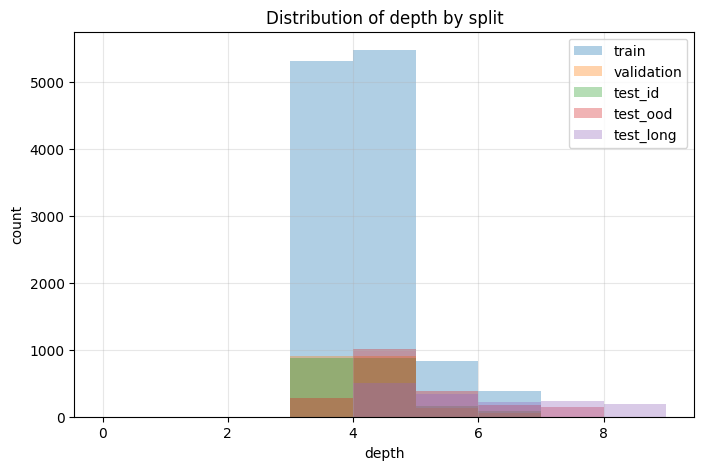

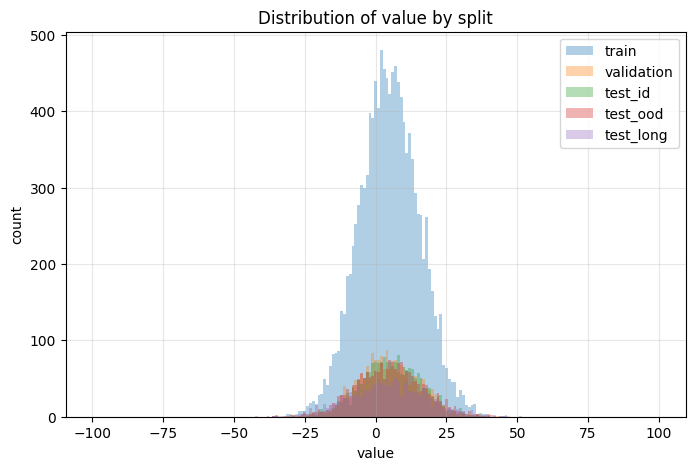

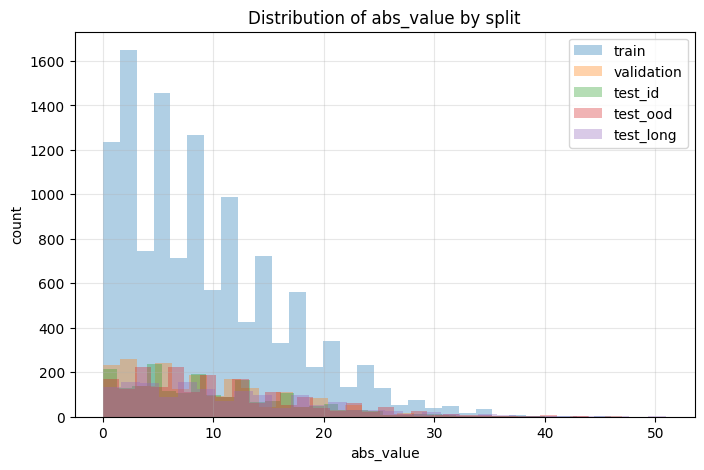

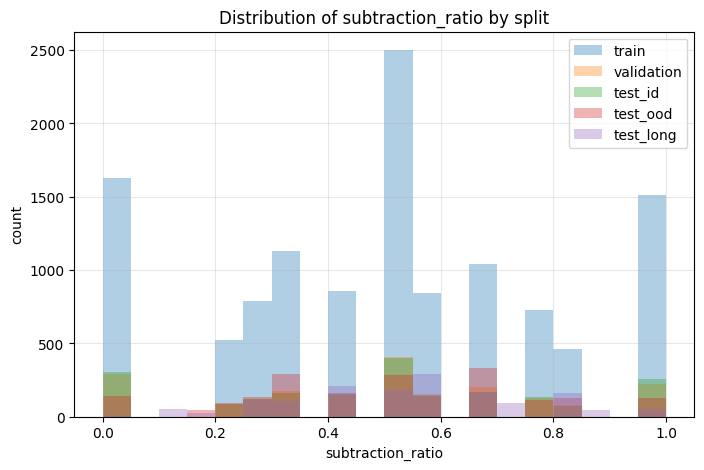

In [ ]:
# -------------------------------------------------------------------------
# Main feature histograms
# -------------------------------------------------------------------------
# Purpose:
#   Visualize the distribution of core dataset features across all splits.
#
# Why these features:
#   - length and operator_count measure sequence/compositional size.
#   - depth approximates hierarchical complexity.
#   - value and abs_value describe the prediction target.
#   - subtraction_ratio captures how subtraction-heavy an expression is.
#
# These plots are directly connected to the project requirement to analyze
# degradation under length, shape/depth, result magnitude, and distribution
# shifts.
# -------------------------------------------------------------------------

# Main histograms

plot_hist_by_split("length", bins=30)
plot_hist_by_split("operator_count", bins=20)
plot_hist_by_split("depth", bins=range(0, int(all_data["depth"].max()) + 2))
plot_hist_by_split("value", bins=np.arange(-99.5, 100.5, 1))
plot_hist_by_split("abs_value", bins=30)
plot_hist_by_split("subtraction_ratio", bins=20)

/tmp/ipykernel_2675/3319665159.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showfliers=showfliers)


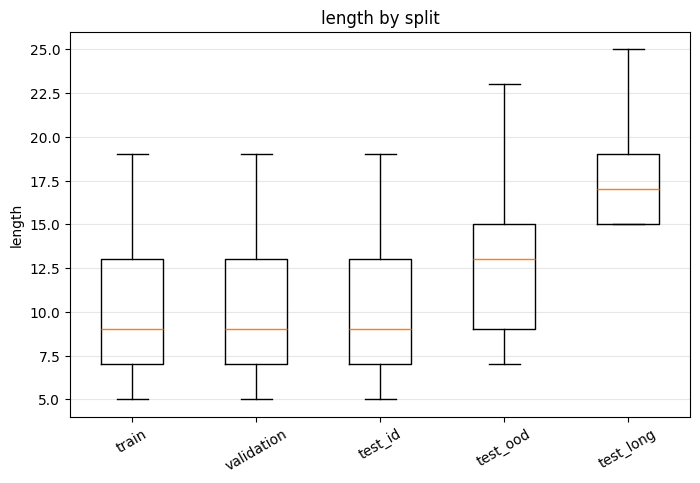

/tmp/ipykernel_2675/3319665159.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showfliers=showfliers)


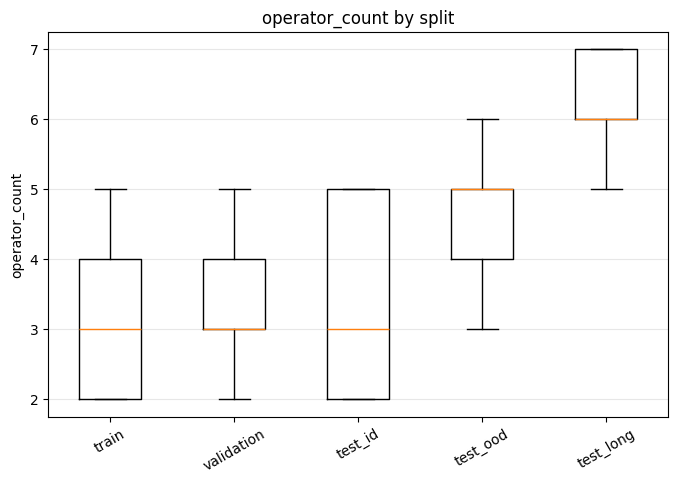

/tmp/ipykernel_2675/3319665159.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showfliers=showfliers)


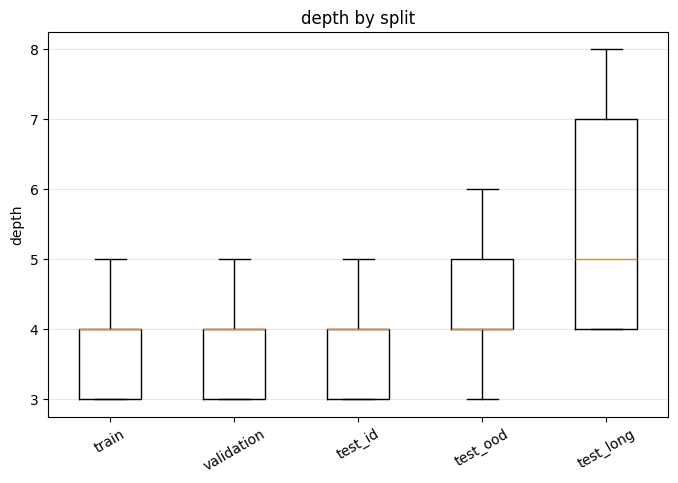

/tmp/ipykernel_2675/3319665159.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showfliers=showfliers)


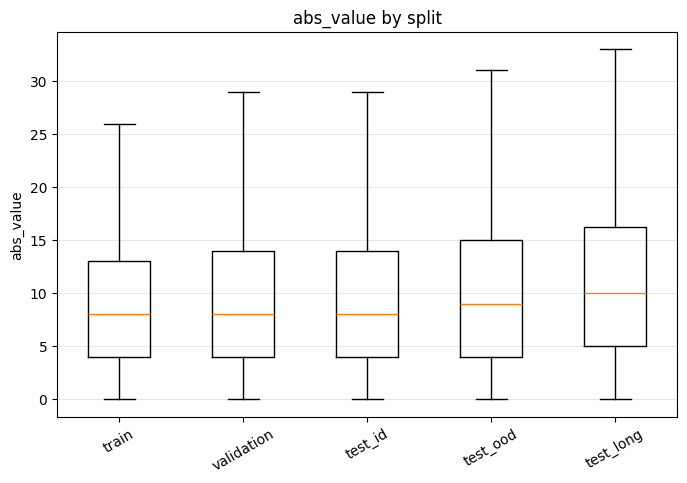

/tmp/ipykernel_2675/3319665159.py:45: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(values, labels=labels, showfliers=showfliers)


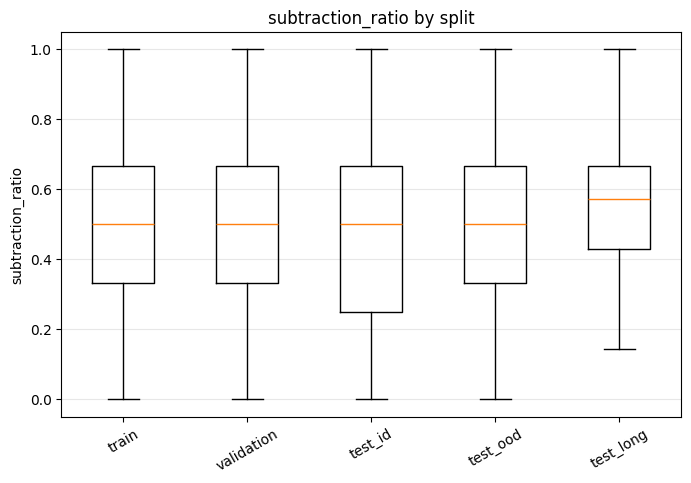

In [ ]:
# -------------------------------------------------------------------------
# Boxplot comparison across splits
# -------------------------------------------------------------------------
# Purpose:
#   Provide a compact visual comparison of the main structural and target
#   features.
#
# Why this complements histograms:
#   Histograms show detailed distributions, while boxplots make it easier to see
#   differences in medians and spread across splits.
# -------------------------------------------------------------------------

# Boxplots for split comparison

for feature in ["length", "operator_count", "depth", "abs_value", "subtraction_ratio"]:
    plot_box_by_split(feature)

Shift analysis with respect to train

In [ ]:
# -------------------------------------------------------------------------
# Shift analysis with respect to the training distribution
# -------------------------------------------------------------------------
# Purpose:
#   Quantify how much each validation/test split differs from the training set.
#
# What this function measures:
#   For each feature, it records train min/max/mean/median and compares them
#   with each split. It also computes the percentage of examples that fall
#   below or above the training range.
#
# Why this is essential:
#   In the Full Practical Track, the key question is extrapolation beyond the
#   training distribution. If test_long has lengths above the train range, or
#   test_ood has higher depth/subtraction ratios, those are explicit sources of
#   distribution shift that we can later relate to model failures.
# -------------------------------------------------------------------------

SHIFT_FEATURES = [
    "length",
    "operator_count",
    "depth",
    "abs_value",
    "binary_minus_count",
    "paren_count",
    "subtraction_ratio",
]

def train_range_shift_report(splits, reference_split="train", features=SHIFT_FEATURES):
    ref = splits[reference_split]
    rows = []

    for feature in features:
        train_min = ref[feature].min()
        train_max = ref[feature].max()
        train_mean = ref[feature].mean()
        train_median = ref[feature].median()

        for split_name, df in splits.items():
            below = (df[feature] < train_min).mean() * 100
            above = (df[feature] > train_max).mean() * 100

            rows.append({
                "feature": feature,
                "split": split_name,

                "train_min": train_min,
                "train_max": train_max,
                "split_min": df[feature].min(),
                "split_max": df[feature].max(),

                "train_mean": train_mean,
                "split_mean": df[feature].mean(),
                "mean_difference": df[feature].mean() - train_mean,

                "train_median": train_median,
                "split_median": df[feature].median(),
                "median_difference": df[feature].median() - train_median,

                "pct_below_train_range": below,
                "pct_above_train_range": above,
                "pct_outside_train_range": below + above,
            })

    return pd.DataFrame(rows)


shift_df = train_range_shift_report(splits)

display(shift_df)

,feature,split,train_min,train_max,split_min,split_max,train_mean,split_mean,mean_difference,train_median,split_median,median_difference,pct_below_train_range,pct_above_train_range,pct_outside_train_range
0,length,train,5.0,19.0,5.0,19.0,9.607000,9.607000,0.000000,9.0,9.000000,0.000000,0.0,0.000000,0.000000
1,length,validation,5.0,19.0,5.0,19.0,9.607000,9.604000,-0.003000,9.0,9.000000,0.000000,0.0,0.000000,0.000000
2,length,test_id,5.0,19.0,5.0,19.0,9.607000,9.609000,0.002000,9.0,9.000000,0.000000,0.0,0.000000,0.000000
3,length,test_ood,5.0,19.0,7.0,23.0,9.607000,12.484000,2.877000,9.0,13.000000,4.000000,0.0,2.100000,2.100000
4,length,test_long,5.0,19.0,15.0,27.0,9.607000,17.744000,8.137000,9.0,17.000000,8.000000,0.0,18.200000,18.200000
5,operator_count,train,2.0,5.0,2.0,5.0,3.489917,3.489917,0.000000,3.0,3.000000,0.000000,0.0,0.000000,0.000000
6,operator_count,validation,2.0,5.0,2.0,5.0,3.489917,3.497000,0.007083,3.0,3.000000,0.000000,0.0,0.000000,0.000000
7,operator_count,test_id,2.0,5.0,2.0,5.0,3.489917,3.487000,-0.002917,3.0,3.000000,0.000000,0.0,0.000000,0.000000
8,operator_count,test_ood,2.0,5.0,3.0,6.0,3.489917,4.515500,1.025583,3.0,5.000000,2.000000,0.0,24.700000,24.700000
9,operator_count,test_long,2.0,5.0,5.0,7.0,3.489917,6.214667,2.724750,3.0,6.000000,3.000000,0.0,79.533333,79.533333


In [ ]:
# -------------------------------------------------------------------------
# Readable view of shift results
# -------------------------------------------------------------------------
# Purpose:
#   Display only validation/test rows, sorted to highlight where the largest
#   out-of-train-range shifts occur.
#
# Why this is useful:
#   The full shift table is complete but dense. This filtered view makes it
#   easier to identify the most problematic splits and features at a glance.
# -------------------------------------------------------------------------

# More readable version: only validation/test splits

display(
    shift_df[shift_df["split"] != "train"]
    .sort_values(["feature", "pct_outside_train_range"], ascending=[True, False])
)

,feature,split,train_min,train_max,split_min,split_max,train_mean,split_mean,mean_difference,train_median,split_median,median_difference,pct_below_train_range,pct_above_train_range,pct_outside_train_range
19,abs_value,test_long,0.0,46.0,0.0,51.0,9.275083,11.287333,2.012250,8.0,10.000000,2.000000,0.0,0.066667,0.066667
16,abs_value,validation,0.0,46.0,0.0,47.0,9.275083,9.233000,-0.042083,8.0,8.000000,0.000000,0.0,0.050000,0.050000
17,abs_value,test_id,0.0,46.0,0.0,40.0,9.275083,9.485500,0.210417,8.0,8.000000,0.000000,0.0,0.000000,0.000000
18,abs_value,test_ood,0.0,46.0,0.0,44.0,9.275083,10.353500,1.078417,8.0,9.000000,1.000000,0.0,0.000000,0.000000
24,binary_minus_count,test_long,0.0,5.0,0.0,7.0,1.714250,3.369333,1.655083,2.0,3.000000,1.000000,0.0,4.333333,4.333333
23,binary_minus_count,test_ood,0.0,5.0,0.0,6.0,1.714250,2.227500,0.513250,2.0,2.000000,0.000000,0.0,0.650000,0.650000
21,binary_minus_count,validation,0.0,5.0,0.0,5.0,1.714250,1.715000,0.000750,2.0,2.000000,0.000000,0.0,0.000000,0.000000
22,binary_minus_count,test_id,0.0,5.0,0.0,5.0,1.714250,1.698500,-0.015750,2.0,2.000000,0.000000,0.0,0.000000,0.000000
14,depth,test_long,3.0,6.0,4.0,8.0,3.689917,5.500667,1.810750,4.0,5.000000,1.000000,0.0,28.000000,28.000000
13,depth,test_ood,3.0,6.0,3.0,7.0,3.689917,4.434500,0.744583,4.0,4.000000,0.000000,0.0,6.900000,6.900000


Character frequency analysis

In [ ]:
# -------------------------------------------------------------------------
# Character frequency analysis
# -------------------------------------------------------------------------
# Purpose:
#   Count how often each character appears in each split.
#
# Why this matters for character-level models:
#   Both the CNN and Transformer will likely consume tokenized characters.
#   Character frequencies reveal whether some splits contain a different mix of
#   digits, operators, or parentheses.
#
# Interpretation:
#   Large differences in '-' or parentheses frequency may explain differences
#   in OOD/long-sequence performance.
# -------------------------------------------------------------------------

def char_frequency(df):
    counter = Counter()

    for expression in df["expression"]:
        counter.update(str(expression))

    table = pd.DataFrame(counter.items(), columns=["char", "count"])
    table = table.sort_values("char").reset_index(drop=True)
    table["frequency"] = table["count"] / table["count"].sum()

    return table


char_tables = {
    name: char_frequency(df)
    for name, df in splits.items()
}

for name, table in char_tables.items():
    print("=" * 70)
    print(name)
    display(table)

train


,char,count,frequency
0,(,9763,0.084687
1,),9763,0.084687
2,+,21308,0.184831
3,-,20571,0.178438
4,0,5386,0.046719
5,1,5354,0.046442
6,2,5381,0.046676
7,3,5469,0.047439
8,4,5293,0.045913
9,5,5425,0.047058


validation


,char,count,frequency
0,(,1610,0.083819
1,),1610,0.083819
2,+,3564,0.185548
3,-,3430,0.178571
4,0,897,0.046699
5,1,878,0.045710
6,2,946,0.049250
7,3,905,0.047116
8,4,875,0.045554
9,5,906,0.047168


test_id


,char,count,frequency
0,(,1635,0.085076
1,),1635,0.085076
2,+,3577,0.186128
3,-,3397,0.176761
4,0,923,0.048028
5,1,937,0.048756
6,2,873,0.045426
7,3,875,0.045530
8,4,912,0.047456
9,5,883,0.045947


test_ood


,char,count,frequency
0,(,2453,0.098246
1,),2453,0.098246
2,+,4576,0.183275
3,-,4455,0.178428
4,0,1111,0.044497
5,1,1072,0.042935
6,2,1098,0.043976
7,3,1114,0.044617
8,4,1111,0.044497
9,5,1107,0.044337


test_long


,char,count,frequency
0,(,3236,0.121581
1,),3236,0.121581
2,+,4268,0.160355
3,-,5054,0.189886
4,0,1063,0.039938
5,1,1075,0.040389
6,2,1053,0.039563
7,3,1069,0.040164
8,4,1128,0.042381
9,5,1054,0.039600


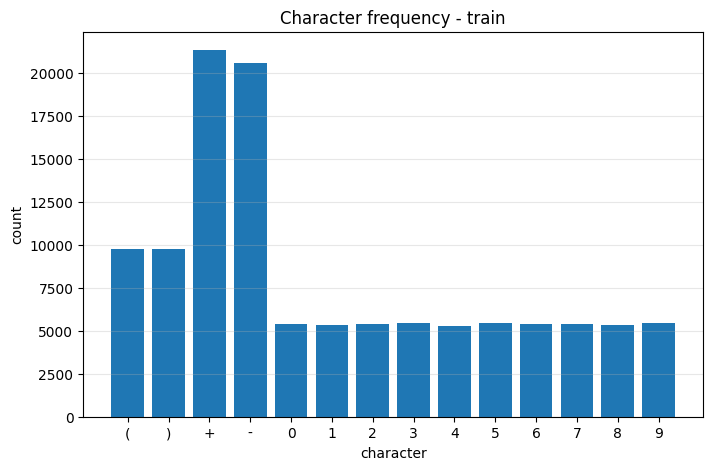

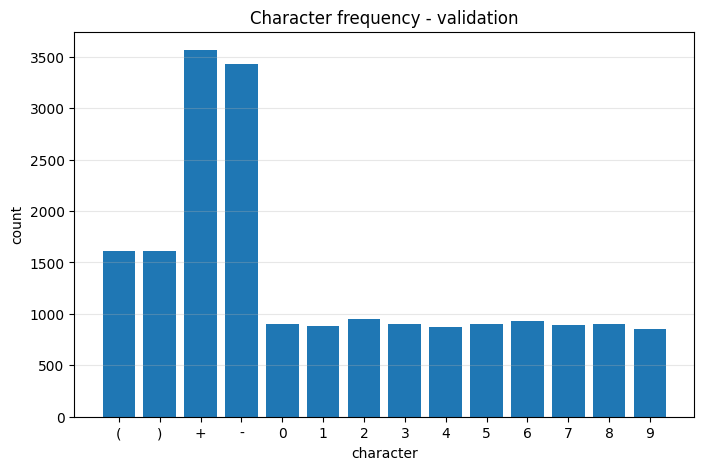

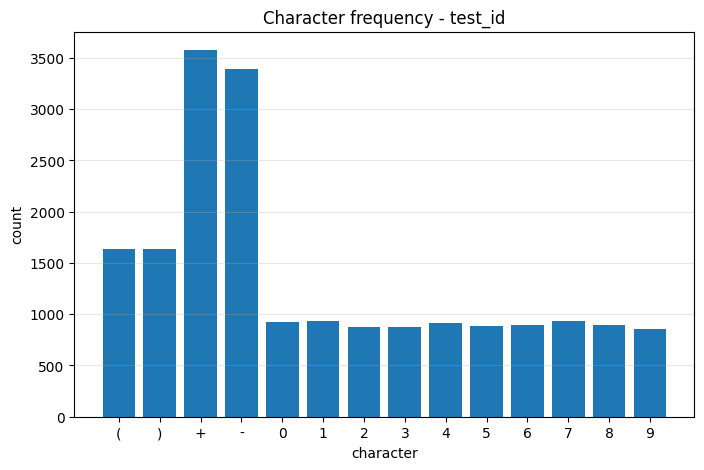

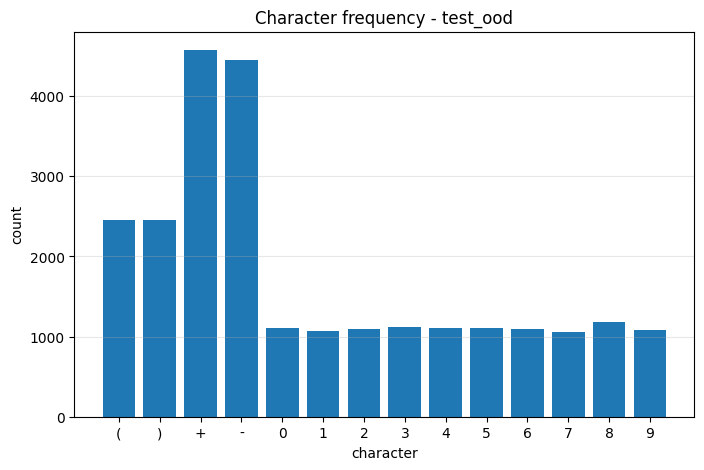

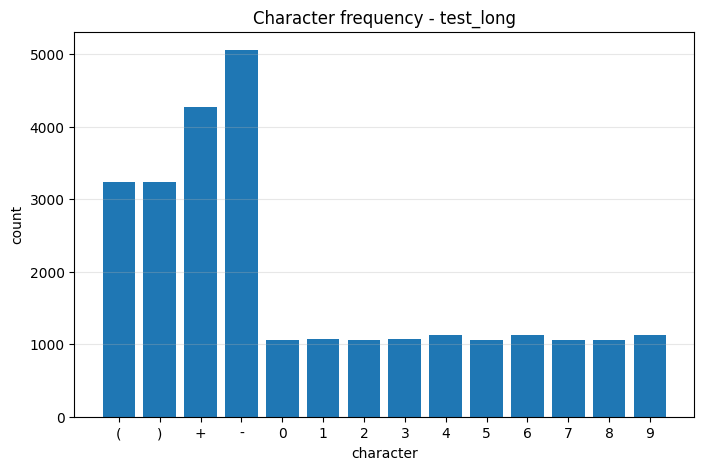

In [ ]:
# -------------------------------------------------------------------------
# Plot character frequencies
# -------------------------------------------------------------------------
# Purpose:
#   Visualize the character-frequency tables for each split.
#
# Why visual plots:
#   Bar charts make it easier to compare the prevalence of digits, operators,
#   and parentheses than raw count tables alone.
# -------------------------------------------------------------------------

def plot_char_frequency(split_name):
    table = char_tables[split_name]

    plt.figure(figsize=(8, 5))
    plt.bar(table["char"], table["count"])
    plt.title(f"Character frequency - {split_name}")
    plt.xlabel("character")
    plt.ylabel("count")
    plt.grid(True, axis="y", alpha=0.3)
    plt.show()


for split_name in splits.keys():
    plot_char_frequency(split_name)

Relation between features

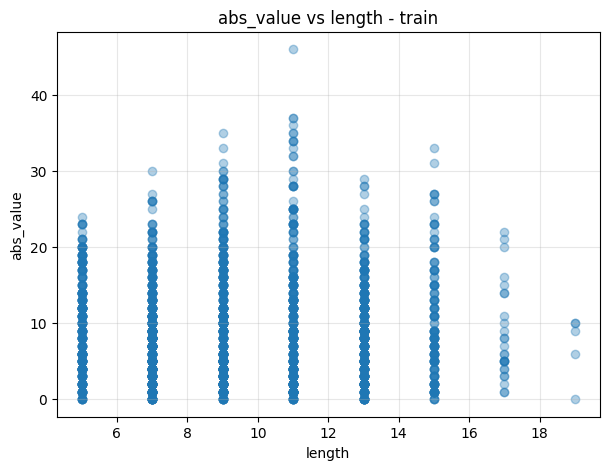

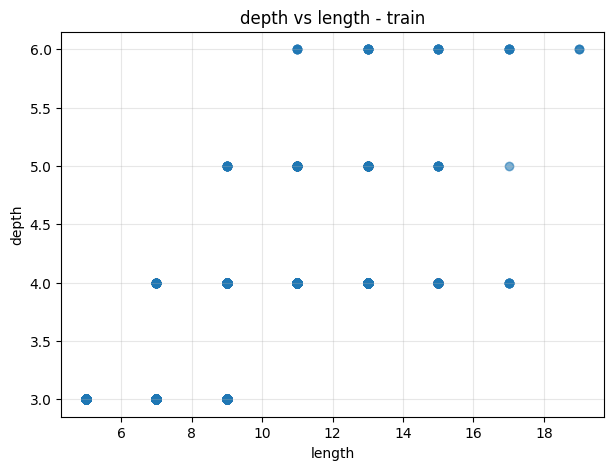

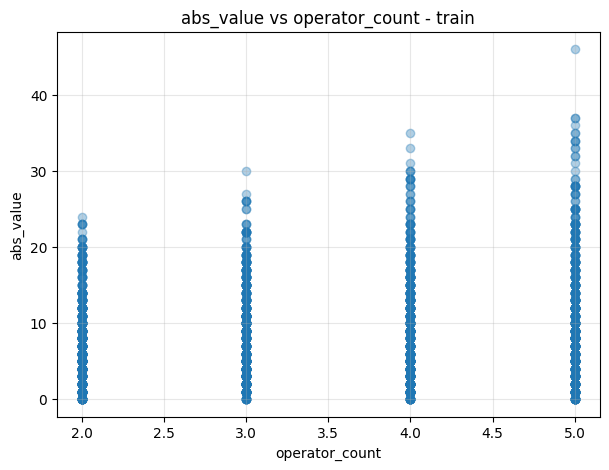

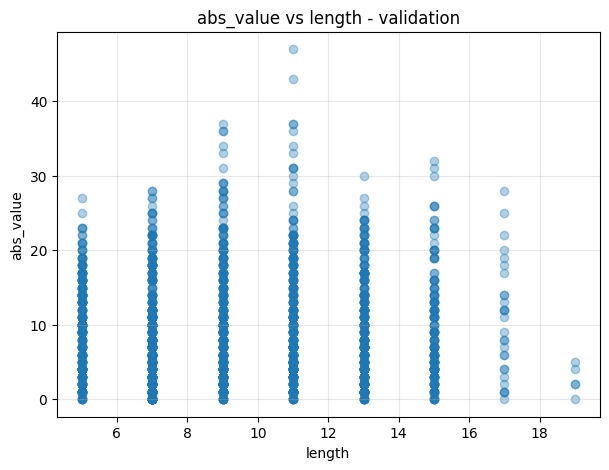

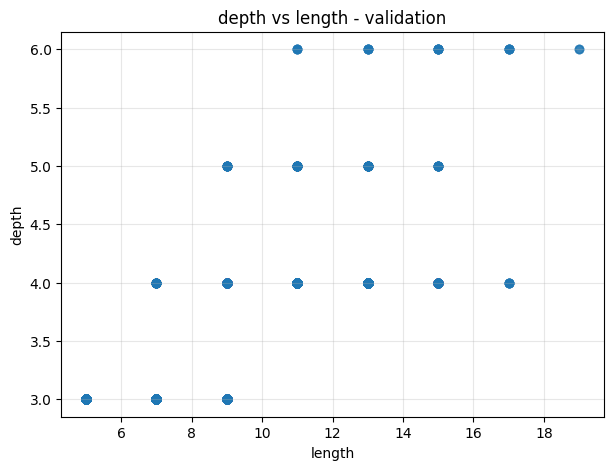

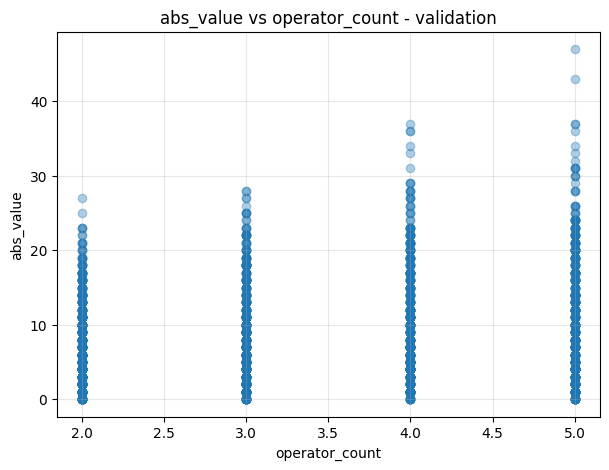

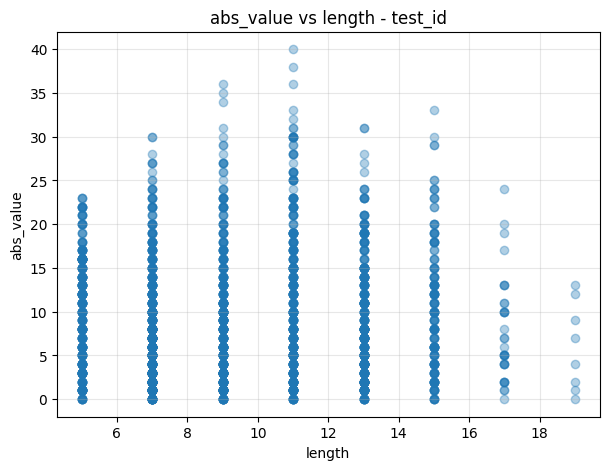

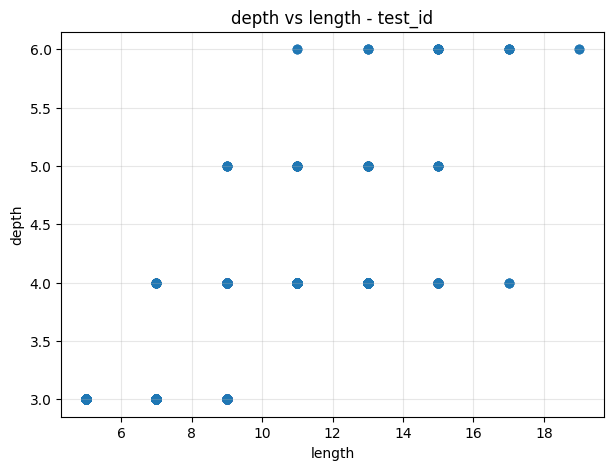

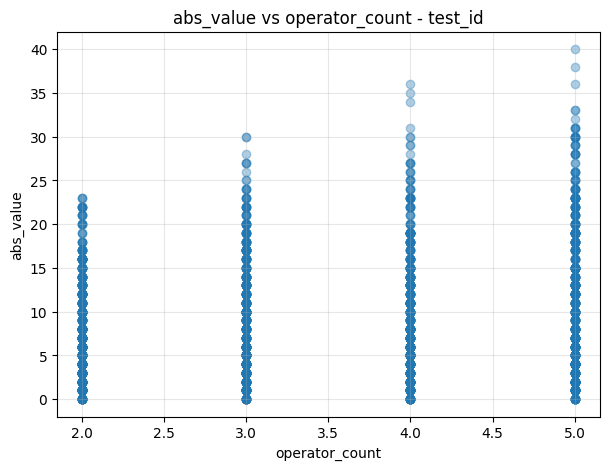

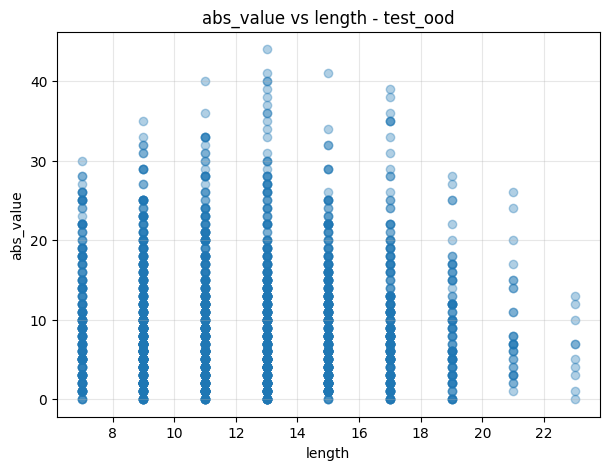

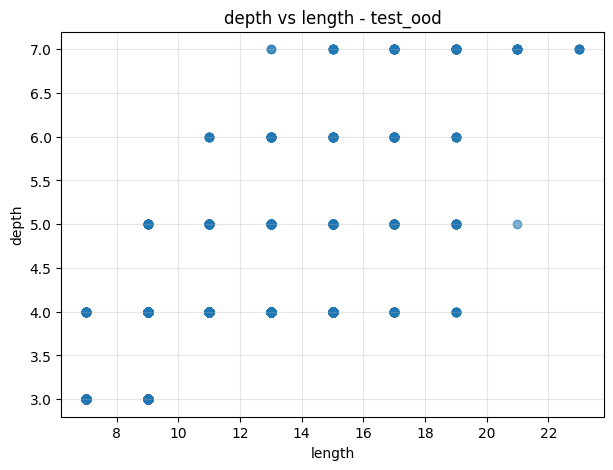

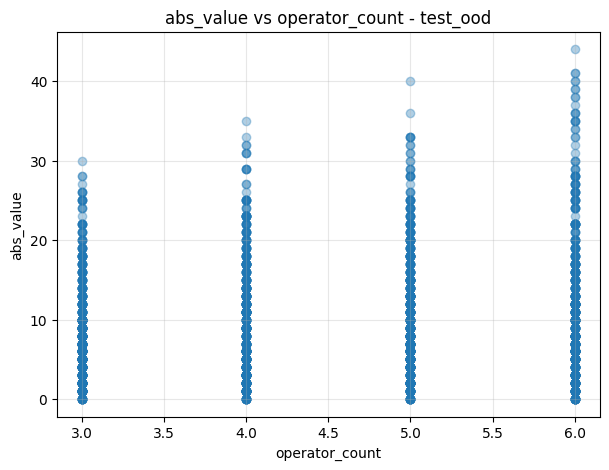

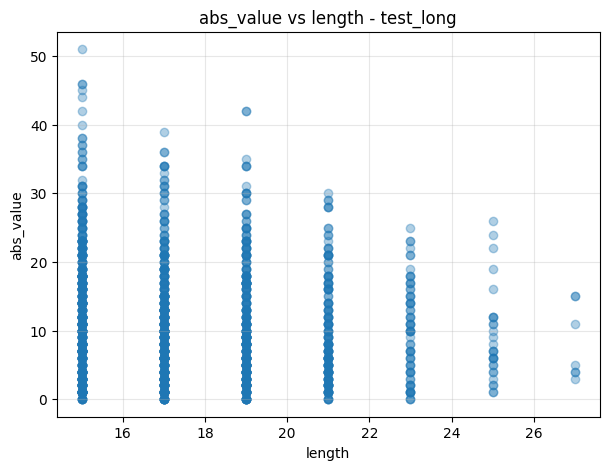

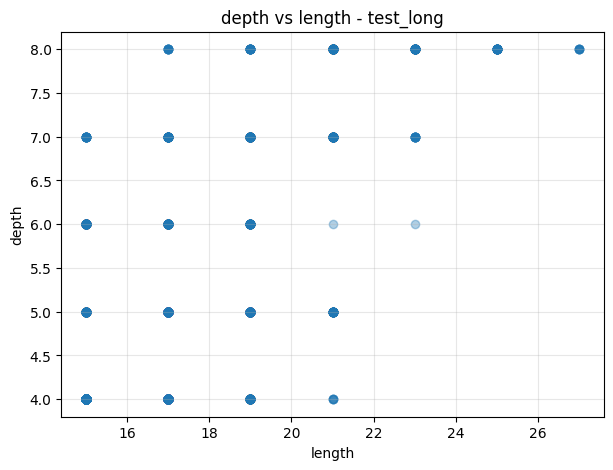

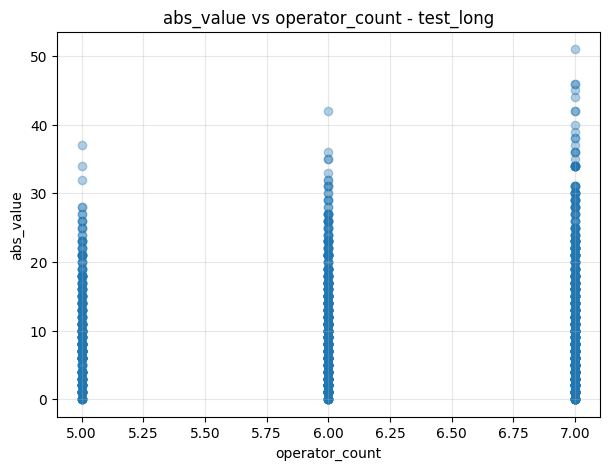

In [ ]:
# -------------------------------------------------------------------------
# Pairwise relationship plots
# -------------------------------------------------------------------------
# Purpose:
#   Visualize relationships between important features within each split.
#
# Relationships plotted:
#   - abs_value vs length: do longer expressions tend to produce larger targets?
#   - depth vs length: are longer expressions also structurally deeper?
#   - abs_value vs operator_count: does more composition increase target size?
#
# Why sampling is used:
#   Sampling keeps plots readable and fast when a split contains many examples.
#   The random_state ensures reproducibility.
# -------------------------------------------------------------------------

def plot_scatter(split_name, x, y, sample_size=2000):
    df = splits[split_name]

    if len(df) > sample_size:
        df = df.sample(sample_size, random_state=42)

    plt.figure(figsize=(7, 5))
    plt.scatter(df[x], df[y], alpha=0.35)
    plt.title(f"{y} vs {x} - {split_name}")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.grid(True, alpha=0.3)
    plt.show()


for split_name in splits.keys():
    plot_scatter(split_name, "length", "abs_value")
    plot_scatter(split_name, "length", "depth")
    plot_scatter(split_name, "operator_count", "abs_value")

Bins for future error analysis

In [ ]:
# -------------------------------------------------------------------------
# Binning features for later error analysis
# -------------------------------------------------------------------------
# Purpose:
#   Convert continuous/integer features into interpretable bins.
#
# Why bins are useful:
#   During model evaluation, we can compute accuracy, MAE, and RMSE per bin.
#   This helps answer questions such as:
#     - Does accuracy drop for longer expressions?
#     - Does the model fail on high-depth expressions?
#     - Are large-magnitude targets harder?
#     - Are subtraction-heavy formulas more difficult?
#
# The bins include values above 21 characters because the Full Practical Track
# includes a long-sequence test set, even though training/validation examples
# and any augmented examples must not exceed 21 characters.
# -------------------------------------------------------------------------

def add_analysis_bins(df):
    df = df.copy()

    df["length_bin"] = pd.cut(
        df["length"],
        bins=[0, 10, 15, 21, 30, 50, np.inf],
        labels=["<=10", "11-15", "16-21", "22-30", "31-50", ">50"],
        include_lowest=True,
    )

    df["depth_bin"] = pd.cut(
        df["depth"],
        bins=[-1, 0, 1, 2, 3, 4, np.inf],
        labels=["0", "1", "2", "3", "4", ">=5"],
    )

    df["abs_value_bin"] = pd.cut(
        df["abs_value"],
        bins=[-1, 5, 10, 20, 40, 70, 99],
        labels=["0-5", "6-10", "11-20", "21-40", "41-70", "71-99"],
    )

    df["subtraction_ratio_bin"] = pd.cut(
        df["subtraction_ratio"],
        bins=[-0.01, 0.25, 0.50, 0.75, 1.0],
        labels=["0-0.25", "0.25-0.50", "0.50-0.75", "0.75-1.00"],
    )

    return df


splits = {
    name: add_analysis_bins(df)
    for name, df in splits.items()
}

all_data = pd.concat(
    [df.assign(split=name) for name, df in splits.items()],
    ignore_index=True
)

all_data.head()

,id,expression,value,length,operator_count,depth,computed_length,contains_whitespace,digit_count,plus_count,minus_count_raw,open_paren_count,close_paren_count,paren_count,unary_minus_count,binary_minus_count,computed_operator_count,subtraction_ratio,computed_depth,parentheses_balanced,abs_value,target_class,value_in_expected_range,target_class_in_range,length_matches_metadata,operator_count_matches_metadata,depth_matches_metadata,length_bin,depth_bin,abs_value_bin,subtraction_ratio_bin,split
0,train-00000,4+4+7+3+8-1,25,11,5,5,11,False,6,4,1,0,0,0,0,1,5,0.20,0,True,25,124,True,True,True,True,False,11-15,>=5,21-40,0-0.25,train
1,train-00001,5-(6-5)+8+8,20,11,4,5,11,False,5,2,2,1,1,2,0,2,4,0.50,1,True,20,119,True,True,True,True,False,11-15,>=5,11-20,0.25-0.50,train
2,train-00002,5-3+1,3,5,2,3,5,False,3,1,1,0,0,0,0,1,2,0.50,0,True,3,102,True,True,True,True,False,<=10,3,0-5,0.25-0.50,train
3,train-00003,1-(1+5+8+7+1),-21,13,5,6,13,False,6,4,1,1,1,2,0,1,5,0.20,1,True,21,78,True,True,True,True,False,11-15,>=5,21-40,0-0.25,train
4,train-00004,7+1-(6+5+9),-12,11,4,4,11,False,5,3,1,1,1,2,0,1,4,0.25,1,True,12,87,True,True,True,True,False,11-15,4,11-20,0-0.25,train


In [ ]:
# -------------------------------------------------------------------------
# Count examples in each analysis bin
# -------------------------------------------------------------------------
# Purpose:
#   Show how many examples from each split fall into each bin.
#
# Why this matters:
#   Per-bin model results are only meaningful if there are enough examples in
#   the bin. This table helps identify sparse regions where conclusions should
#   be made carefully.
# -------------------------------------------------------------------------

# Count examples per bin and split

for bin_col in ["length_bin", "depth_bin", "abs_value_bin", "subtraction_ratio_bin"]:
    print("=" * 70)
    print(bin_col)
    display(pd.crosstab(all_data["split"], all_data[bin_col], margins=True))

length_bin


length_bin,<=10,11-15,16-21,22-30,All
split,,,,,
test_id,1123,836,41,0,2000
test_long,0,468,928,104,1500
test_ood,584,1062,344,10,2000
train,6773,5011,216,0,12000
validation,1129,838,33,0,2000
All,9609,8215,1562,114,19500


depth_bin


depth_bin,3,4,>=5,All
split,,,,
test_id,879,883,238,2000
test_long,0,507,993,1500
test_ood,285,1012,703,2000
train,5313,5477,1210,12000
validation,901,901,198,2000
All,7378,8780,3342,19500


abs_value_bin


abs_value_bin,0-5,6-10,11-20,21-40,41-70,All
split,,,,,,
test_id,716,506,614,164,0,2000
test_long,438,367,467,220,8,1500
test_ood,645,524,604,224,3,2000
train,4352,3277,3443,925,3,12000
validation,744,522,576,156,2,2000
All,6895,5196,5704,1689,16,19500


subtraction_ratio_bin


subtraction_ratio_bin,0-0.25,0.25-0.50,0.50-0.75,0.75-1.00,All
split,,,,,
test_id,509,712,448,331,2000
test_long,85,607,554,254,1500
test_ood,418,735,592,255,2000
train,2934,4483,2615,1968,12000
validation,491,727,481,301,2000
All,4437,7264,4690,3109,19500


Save EDA tables

In [ ]:
# -------------------------------------------------------------------------
# Save core EDA tables
# -------------------------------------------------------------------------
# Purpose:
#   Export the most important EDA tables to CSV files.
#
# Why saving outputs is useful:
#   These CSV files can be reused when writing the report, creating plots, or
#   comparing later model results without rerunning the entire notebook.
#
# Colab note:
#   The path /content/eda_outputs exists only in the current Colab runtime unless
#   the files are downloaded or copied elsewhere.
# -------------------------------------------------------------------------

OUTPUT_DIR = Path("/content/eda_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

summary_df.to_csv(OUTPUT_DIR / "split_summary.csv", index=False)
detailed_summary_df.to_csv(OUTPUT_DIR / "detailed_numeric_summary.csv")
overlap_df.to_csv(OUTPUT_DIR / "split_overlap_report.csv", index=False)
shift_df.to_csv(OUTPUT_DIR / "shift_report_vs_train.csv", index=False)

for name, table in char_tables.items():
    table.to_csv(OUTPUT_DIR / f"char_frequency_{name}.csv", index=False)

print(f"EDA outputs saved in: {OUTPUT_DIR}")

EDA outputs saved in: /content/eda_outputs


## Additional EDA for Full Practical Track

This final section adds a few targeted analyses for the *Full Practical Track*: support overlap, structural distribution shifts, operator patterns, parenthesis usage, and interaction plots that will be useful for the report and for the later error analysis of the CNN and Transformer models.

In [ ]:
# -------------------------------------------------------------------------
# Additional Full Practical Track EDA setup
# -------------------------------------------------------------------------
# Purpose:
#   Prepare extra structural features and combined tables specifically aimed at
#   analyzing extrapolation and distribution shift.
#
# Why this section was added:
#   The Full Practical Track requires a detailed discussion of extrapolation
#   behavior, especially with respect to sequence length, expression shape,
#   parenthesis/depth effects, target magnitude, and other shifts. The following
#   analyses are designed to support that discussion with evidence.
#
# Compliance note:
#   As before, this cell only counts and describes expressions. It does not
#   compute the arithmetic result from the string.
# -------------------------------------------------------------------------

# ============================================================
# Additional EDA for Full Practical Track: generalization shift
# ============================================================

# This cell is designed to work with the existing notebook variables:
# - splits: dictionary mapping split names to DataFrames
# - all_data: concatenation of all splits with a "split" column
#
# It does not evaluate expressions and does not perform symbolic computation.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter


def ensure_additional_features(df):
    """
    Adds structural features useful for generalization analysis.
    This function only counts characters/patterns; it does not evaluate expressions.
    """
    df = df.copy()

    if "plus_count" not in df.columns:
        df["plus_count"] = df["expression"].astype(str).str.count(r"\+")

    if "binary_minus_count" not in df.columns:
        df["binary_minus_count"] = df["expression"].astype(str).str.count(r"-")

    if "paren_open_count" not in df.columns:
        df["paren_open_count"] = df["expression"].astype(str).str.count(r"\(")

    if "paren_close_count" not in df.columns:
        df["paren_close_count"] = df["expression"].astype(str).str.count(r"\)")

    if "paren_count" not in df.columns:
        df["paren_count"] = df["paren_open_count"] + df["paren_close_count"]

    if "subtraction_ratio" not in df.columns:
        df["subtraction_ratio"] = np.where(
            df["operator_count"] > 0,
            df["binary_minus_count"] / df["operator_count"],
            0.0,
        )

    if "abs_value" not in df.columns:
        df["abs_value"] = df["value"].abs()

    df["has_parentheses"] = df["paren_count"] > 0

    return df


splits_ext = {
    name: ensure_additional_features(df)
    for name, df in splits.items()
}

all_data_ext = pd.concat(
    [df.assign(split=name) for name, df in splits_ext.items()],
    ignore_index=True,
)

print("Additional feature columns available:")
print([
    "plus_count", "binary_minus_count", "paren_open_count", "paren_close_count",
    "paren_count", "subtraction_ratio", "abs_value", "has_parentheses"
])

Additional feature columns available:
['plus_count', 'binary_minus_count', 'paren_open_count', 'paren_close_count', 'paren_count', 'subtraction_ratio', 'abs_value', 'has_parentheses']


In [ ]:
# -------------------------------------------------------------------------
# Additional compact structural summary
# -------------------------------------------------------------------------
# Purpose:
#   Create a concise table focused on the features most relevant for
#   generalization: length, depth, operator count, subtraction ratio,
#   parentheses usage, and target magnitude.
#
# Why this is useful:
#   This table is suitable for quick inspection and can be summarized in the
#   report to explain how the long-sequence and OOD splits differ from train.
# -------------------------------------------------------------------------

# ------------------------------------------------------------
# 1. Compact structural summary by split
# ------------------------------------------------------------

additional_summary_rows = []

for name, df in splits_ext.items():
    additional_summary_rows.append({
        "split": name,
        "n_examples": len(df),
        "length_min": df["length"].min(),
        "length_mean": df["length"].mean(),
        "length_max": df["length"].max(),
        "depth_min": df["depth"].min(),
        "depth_mean": df["depth"].mean(),
        "depth_max": df["depth"].max(),
        "operator_count_mean": df["operator_count"].mean(),
        "subtraction_ratio_mean": df["subtraction_ratio"].mean(),
        "parentheses_pct": 100 * df["has_parentheses"].mean(),
        "target_min": df["value"].min(),
        "target_max": df["value"].max(),
        "abs_target_mean": df["abs_value"].mean(),
        "abs_target_max": df["abs_value"].max(),
    })

additional_summary_df = pd.DataFrame(additional_summary_rows)
display(additional_summary_df.round(3))

,split,n_examples,length_min,length_mean,length_max,depth_min,depth_mean,depth_max,operator_count_mean,subtraction_ratio_mean,parentheses_pct,target_min,target_max,abs_target_mean,abs_target_max
0,train,12000,5,9.607,19,3,3.690,6,3.490,0.491,61.958,-36,46,9.275,46
1,validation,2000,5,9.604,19,3,3.679,6,3.497,0.487,61.300,-32,47,9.233,47
2,test_id,2000,5,9.609,19,3,3.722,6,3.487,0.489,61.350,-29,40,9.486,40
3,test_ood,2000,7,12.484,23,3,4.434,7,4.516,0.494,74.250,-38,44,10.354,44
4,test_long,1500,15,17.744,27,4,5.501,8,6.215,0.550,95.267,-42,51,11.287,51


In [ ]:
# -------------------------------------------------------------------------
# Support overlap with the training split
# -------------------------------------------------------------------------
# Purpose:
#   For length, depth, and operator_count, identify which values appear in a
#   test/validation split but never appear in train.
#
# Why this matters:
#   Values that are absent from train represent true support extrapolation. For
#   example, if test_long contains lengths not seen during training, the model
#   must extrapolate rather than interpolate.
#
# Interpretation:
#   The only_split_values column is especially important for explaining where
#   the long-sequence test set goes beyond the training distribution.
# -------------------------------------------------------------------------

# ------------------------------------------------------------
# 2. Train support overlap for length, depth, and operator_count
# ------------------------------------------------------------


def support_overlap(reference_df, other_df, feature):
    reference_values = set(reference_df[feature].dropna().unique())
    other_values = set(other_df[feature].dropna().unique())

    common = reference_values & other_values
    only_other = other_values - reference_values

    return {
        "feature": feature,
        "train_unique": len(reference_values),
        "split_unique": len(other_values),
        "common_unique": len(common),
        "only_split_unique": len(only_other),
        "only_split_values": sorted(list(only_other)),
    }


support_rows = []

for split_name in [name for name in splits_ext.keys() if name != "train"]:
    for feature in ["length", "depth", "operator_count"]:
        row = support_overlap(splits_ext["train"], splits_ext[split_name], feature)
        row["split"] = split_name
        support_rows.append(row)

support_overlap_df = pd.DataFrame(support_rows)
display(support_overlap_df)

,feature,train_unique,split_unique,common_unique,only_split_unique,only_split_values,split
0,length,8,8,8,0,[],validation
1,depth,4,4,4,0,[],validation
2,operator_count,4,4,4,0,[],validation
3,length,8,8,8,0,[],test_id
4,depth,4,4,4,0,[],test_id
5,operator_count,4,4,4,0,[],test_id
6,length,8,9,7,2,"[21, 23]",test_ood
7,depth,4,5,4,1,[7],test_ood
8,operator_count,4,4,3,1,[6],test_ood
9,length,8,7,3,4,"[21, 23, 25, 27]",test_long


In [ ]:
# -------------------------------------------------------------------------
# Percentage distributions over analysis bins
# -------------------------------------------------------------------------
# Purpose:
#   Normalize bin counts by split to obtain comparable percentages.
#
# Why normalization matters:
#   Splits have different sizes, so raw counts can be misleading. Percentages
#   make it easier to compare how much of each split belongs to each length,
#   depth, target-magnitude, or subtraction-ratio bin.
# -------------------------------------------------------------------------

# ------------------------------------------------------------
# 3. Percentage distributions over existing bins
# ------------------------------------------------------------

# These bin columns were already created above in the notebook.
# The tables below are normalized by split, so they are easier to compare.

bin_columns = [
    "length_bin",
    "depth_bin",
    "abs_value_bin",
    "subtraction_ratio_bin",
]

for bin_col in bin_columns:
    if bin_col not in all_data_ext.columns:
        print(f"Skipping {bin_col}: column not found.")
        continue

    print("=" * 70)
    print(f"Percentage distribution by {bin_col}")

    table = pd.crosstab(
        all_data_ext["split"],
        all_data_ext[bin_col],
        normalize="index",
    ) * 100

    display(table.round(2))

Percentage distribution by length_bin


length_bin,<=10,11-15,16-21,22-30
split,,,,
test_id,56.15,41.80,2.05,0.00
test_long,0.00,31.20,61.87,6.93
test_ood,29.20,53.10,17.20,0.50
train,56.44,41.76,1.80,0.00
validation,56.45,41.90,1.65,0.00


Percentage distribution by depth_bin


depth_bin,3,4,>=5
split,,,
test_id,43.95,44.15,11.90
test_long,0.00,33.80,66.20
test_ood,14.25,50.60,35.15
train,44.28,45.64,10.08
validation,45.05,45.05,9.90


Percentage distribution by abs_value_bin


abs_value_bin,0-5,6-10,11-20,21-40,41-70
split,,,,,
test_id,35.80,25.30,30.70,8.20,0.00
test_long,29.20,24.47,31.13,14.67,0.53
test_ood,32.25,26.20,30.20,11.20,0.15
train,36.27,27.31,28.69,7.71,0.02
validation,37.20,26.10,28.80,7.80,0.10


Percentage distribution by subtraction_ratio_bin


subtraction_ratio_bin,0-0.25,0.25-0.50,0.50-0.75,0.75-1.00
split,,,,
test_id,25.45,35.60,22.40,16.55
test_long,5.67,40.47,36.93,16.93
test_ood,20.90,36.75,29.60,12.75
train,24.45,37.36,21.79,16.40
validation,24.55,36.35,24.05,15.05


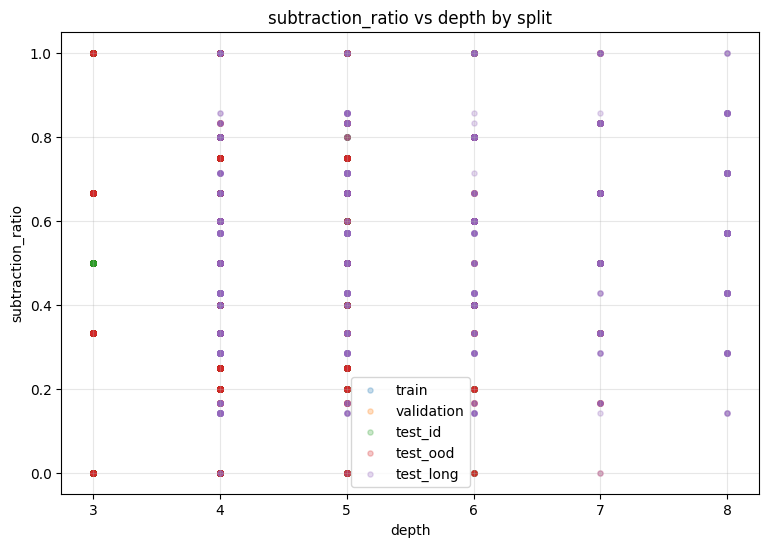

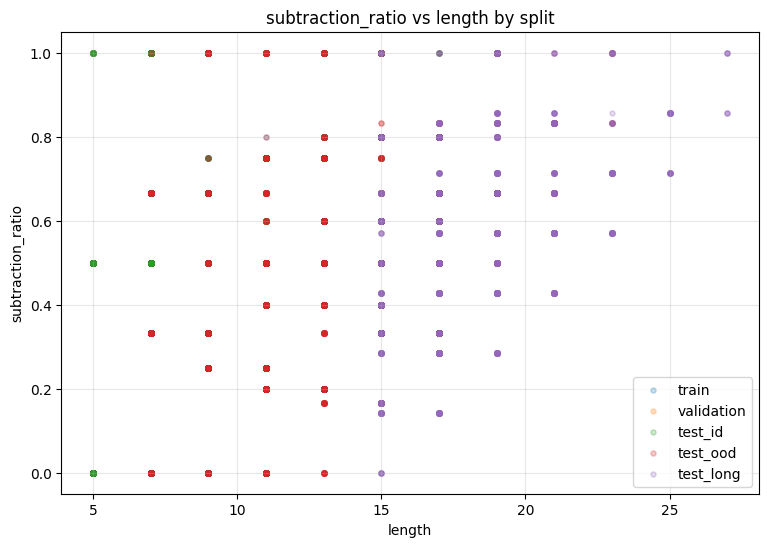

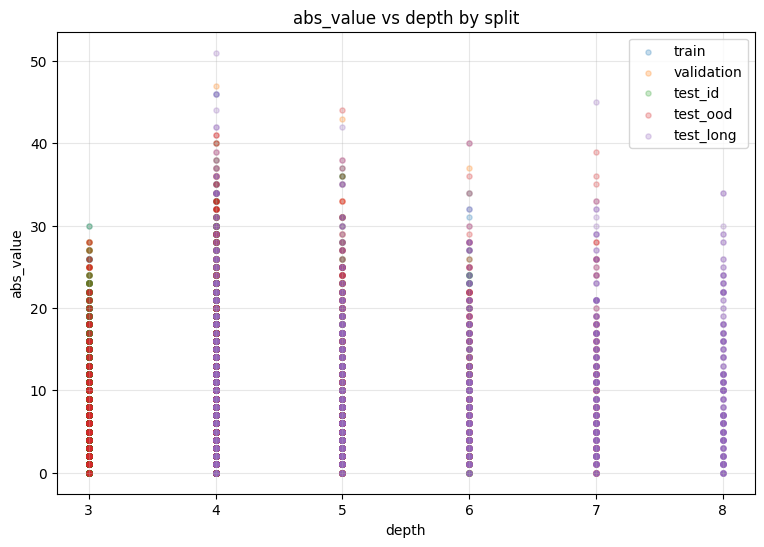

In [ ]:
# -------------------------------------------------------------------------
# Interaction plots between structural variables
# -------------------------------------------------------------------------
# Purpose:
#   Plot pairs of features that may jointly influence task difficulty.
#
# Why interactions matter:
#   Model errors may not depend on a single variable alone. For example, high
#   depth combined with a high subtraction ratio may be harder than either high
#   depth or high subtraction alone.
#
# These plots help identify clusters or regions where OOD/long examples differ
# from the training distribution.
# -------------------------------------------------------------------------

# ------------------------------------------------------------
# 4. Interaction plots: depth, subtraction ratio, and target magnitude
# ------------------------------------------------------------


def scatter_by_split(x, y, sample_size=2500):
    plt.figure(figsize=(9, 6))

    for name, df in splits_ext.items():
        plot_df = df
        if len(plot_df) > sample_size:
            plot_df = plot_df.sample(sample_size, random_state=42)

        plt.scatter(plot_df[x], plot_df[y], alpha=0.25, s=14, label=name)

    plt.title(f"{y} vs {x} by split")
    plt.xlabel(x)
    plt.ylabel(y)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


scatter_by_split("depth", "subtraction_ratio")
scatter_by_split("length", "subtraction_ratio")
scatter_by_split("depth", "abs_value")

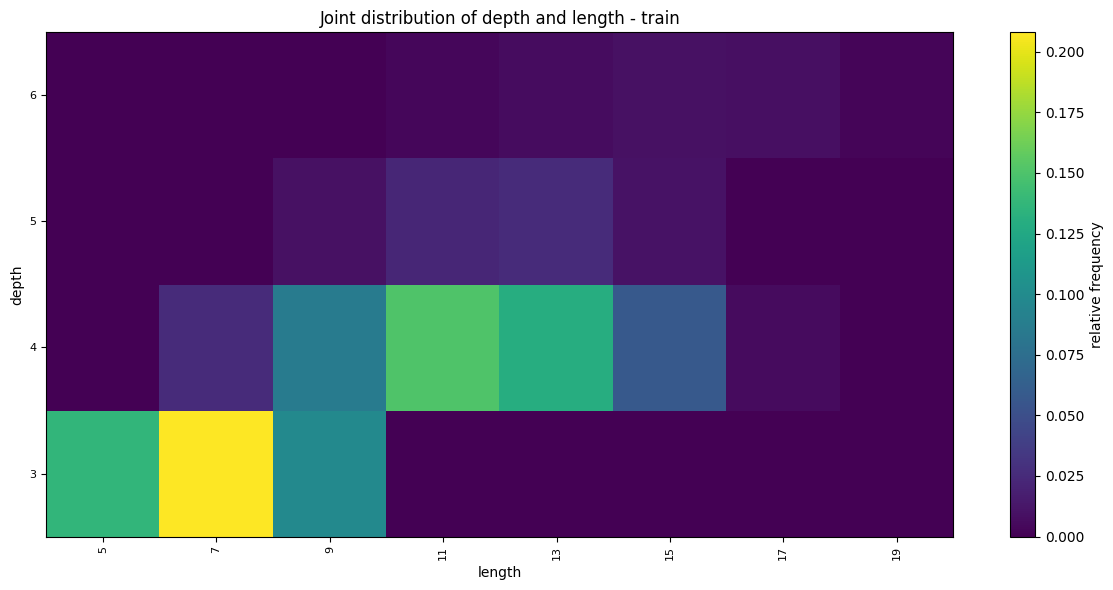

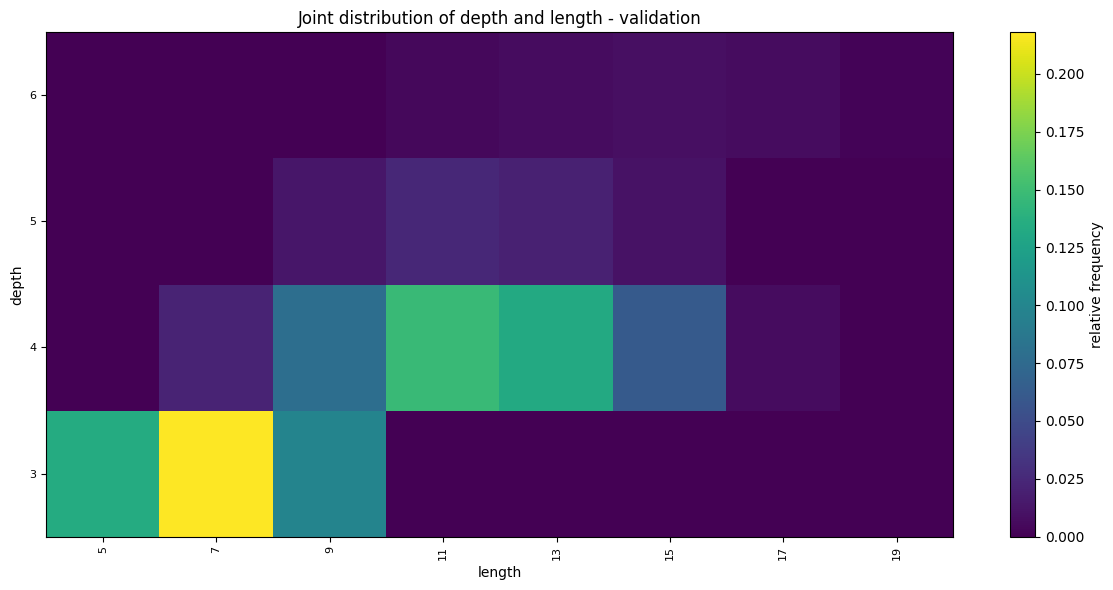

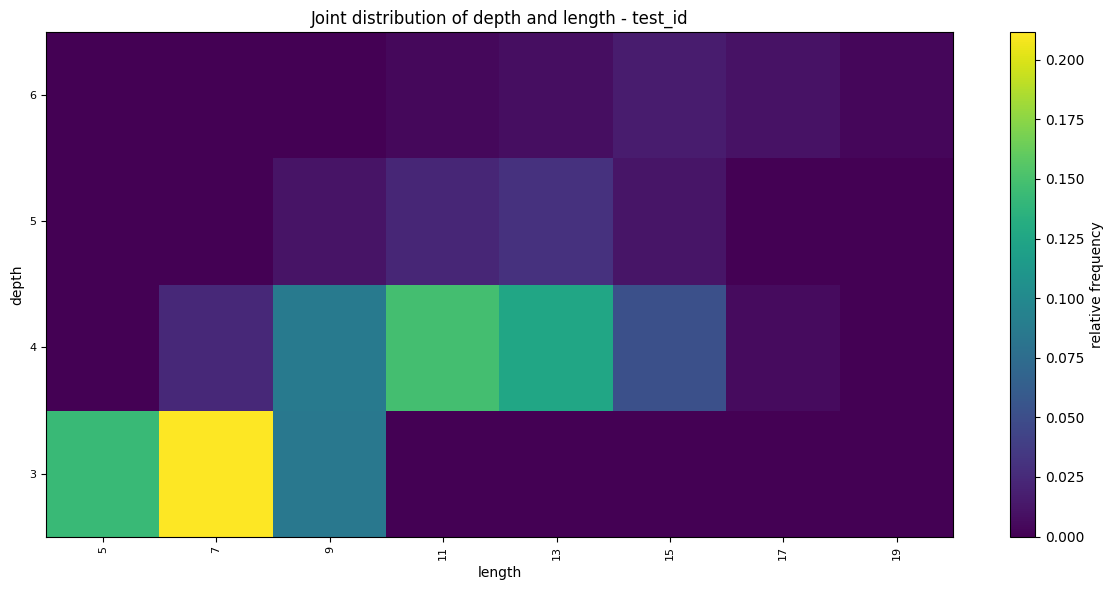

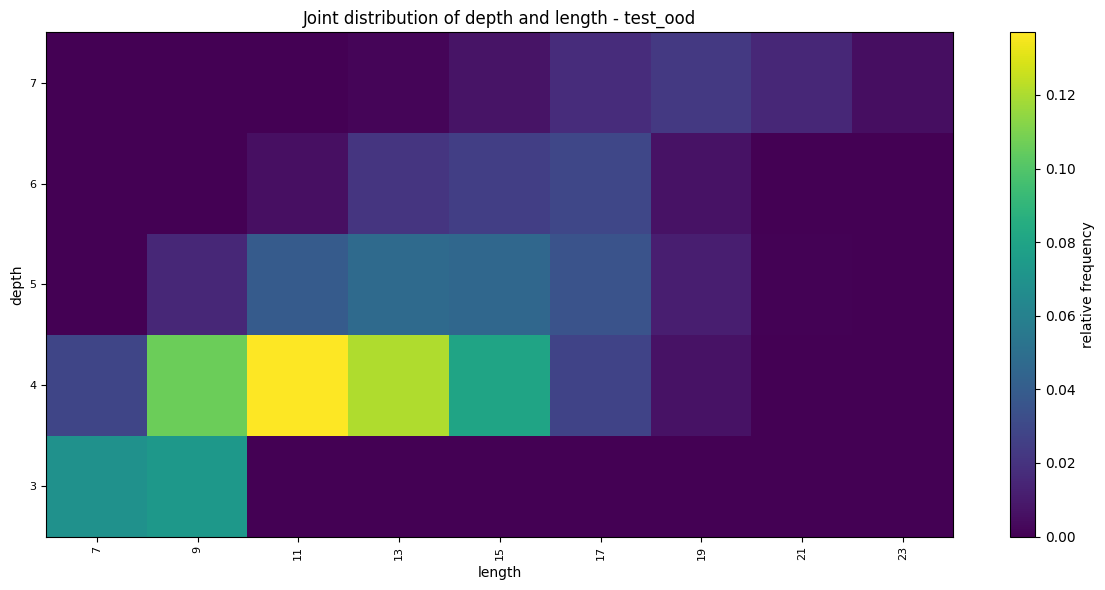

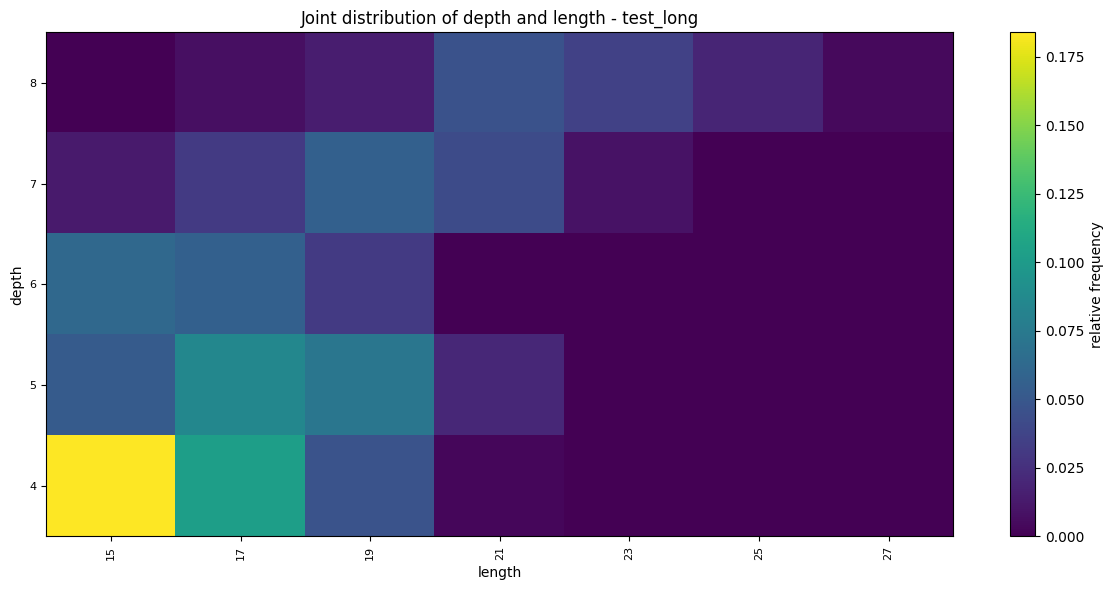

In [ ]:
# -------------------------------------------------------------------------
# Joint distribution maps for length and depth
# -------------------------------------------------------------------------
# Purpose:
#   Visualize the joint distribution of expression length and depth for each
#   split.
#
# Why this is important:
#   Length and depth are related but not identical. A sequence can be long but
#   shallow, or shorter but deeply nested. Since the project asks whether
#   degradation is caused by length, shape, or depth, this joint view is more
#   informative than separate one-dimensional histograms.
# -------------------------------------------------------------------------

# ------------------------------------------------------------
# 5. Joint distribution maps: length vs depth
# ------------------------------------------------------------

for name, df in splits_ext.items():
    pivot = pd.crosstab(df["depth"], df["length"], normalize=True)

    plt.figure(figsize=(12, 6))
    plt.imshow(pivot.values, aspect="auto", origin="lower")
    plt.colorbar(label="relative frequency")
    plt.title(f"Joint distribution of depth and length - {name}")
    plt.xlabel("length")
    plt.ylabel("depth")

    plt.xticks(
        ticks=np.arange(len(pivot.columns)),
        labels=pivot.columns,
        rotation=90,
        fontsize=8,
    )
    plt.yticks(
        ticks=np.arange(len(pivot.index)),
        labels=pivot.index,
        fontsize=8,
    )

    plt.tight_layout()
    plt.show()

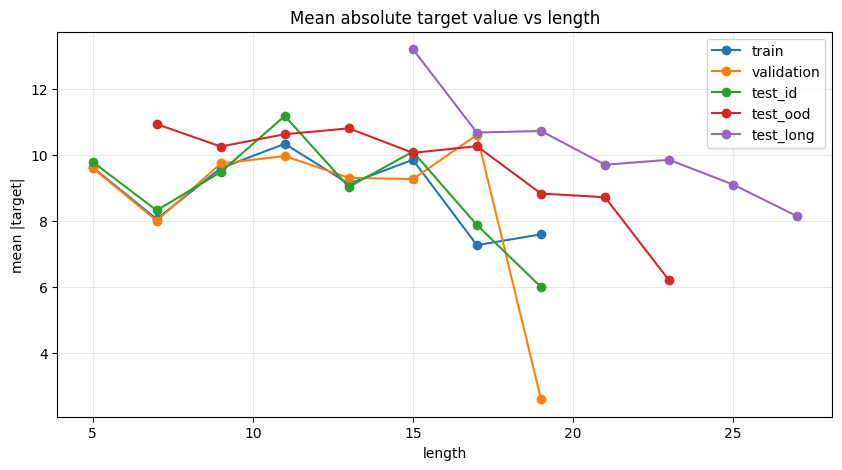

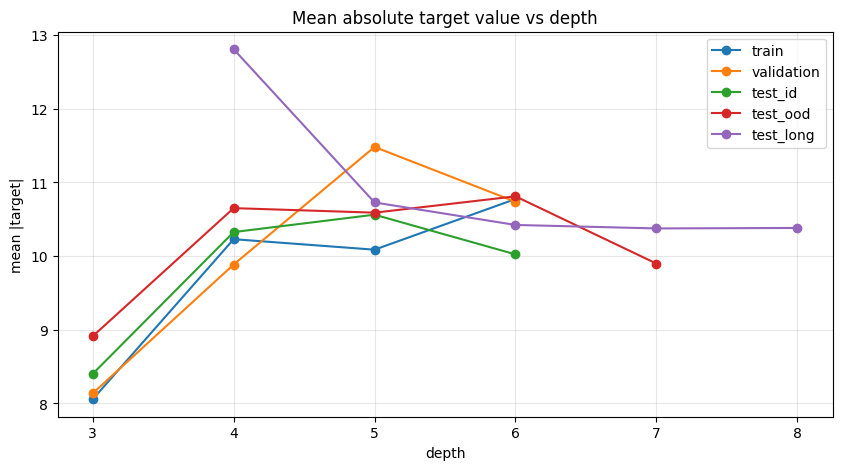

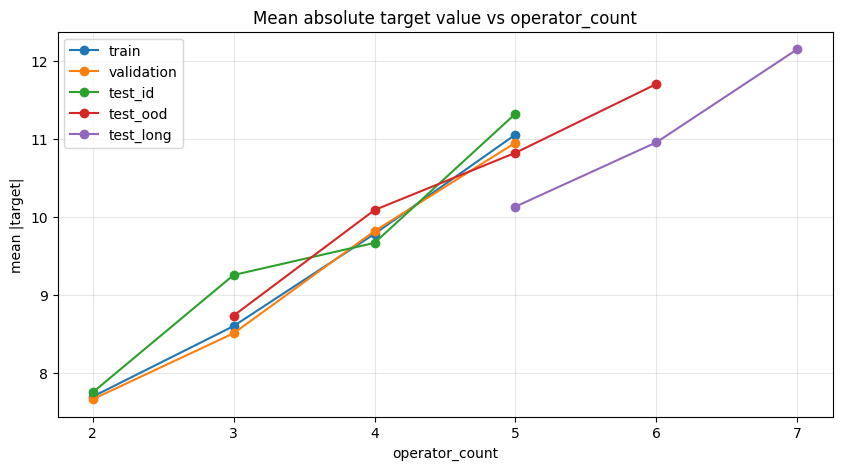

In [ ]:
# -------------------------------------------------------------------------
# Target magnitude versus structural complexity
# -------------------------------------------------------------------------
# Purpose:
#   Measure how the average absolute target value changes with length, depth,
#   and operator count.
#
# Why this matters:
#   If more complex expressions also tend to produce larger-magnitude outputs,
#   then model failures on complex expressions might be partly due to target
#   magnitude rather than structure alone. This plot helps disentangle those
#   factors.
# -------------------------------------------------------------------------

# ------------------------------------------------------------
# 6. Target magnitude as a function of structural complexity
# ------------------------------------------------------------

for feature in ["length", "depth", "operator_count"]:
    plt.figure(figsize=(10, 5))

    for name, df in splits_ext.items():
        grouped = df.groupby(feature)["abs_value"].mean()
        plt.plot(grouped.index, grouped.values, marker="o", label=name)

    plt.title(f"Mean absolute target value vs {feature}")
    plt.xlabel(feature)
    plt.ylabel("mean |target|")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

In [ ]:
# -------------------------------------------------------------------------
# Operator-pattern analysis
# -------------------------------------------------------------------------
# Purpose:
#   Extract only the sequence of '+' and '-' operators from each expression and
#   summarize the most common patterns.
#
# Why this is useful:
#   The OOD split may differ not only in length or depth but also in the pattern
#   of additions and subtractions. Since subtraction changes signs and interacts
#   with parentheses, operator patterns can strongly affect difficulty.
#
# Compliance note:
#   This does not evaluate the expression; it only removes digits and
#   parentheses to inspect the operator sequence.
# -------------------------------------------------------------------------

# ------------------------------------------------------------
# 7. Operator-pattern analysis
# ------------------------------------------------------------


def operator_pattern(expression):
    """Returns the sequence of + and - operators only."""
    return "".join(ch for ch in str(expression) if ch in "+-")


splits_patterns = {}
for name, df in splits_ext.items():
    tmp = df.copy()
    tmp["operator_pattern"] = tmp["expression"].apply(operator_pattern)
    splits_patterns[name] = tmp

pattern_summary_rows = []

for name, df in splits_patterns.items():
    value_counts = df["operator_pattern"].value_counts()

    pattern_summary_rows.append({
        "split": name,
        "unique_operator_patterns": df["operator_pattern"].nunique(),
        "most_common_pattern": value_counts.index[0],
        "most_common_pattern_count": value_counts.iloc[0],
        "most_common_pattern_pct": 100 * value_counts.iloc[0] / len(df),
    })

pattern_summary_df = pd.DataFrame(pattern_summary_rows)
display(pattern_summary_df.round(3))

for name, df in splits_patterns.items():
    print("=" * 70)
    print(f"Top operator patterns - {name}")
    display(df["operator_pattern"].value_counts().head(10).to_frame("count"))

,split,unique_operator_patterns,most_common_pattern,most_common_pattern_count,most_common_pattern_pct
0,train,60,++,831,6.925
1,validation,60,++,152,7.600
2,test_id,60,++,151,7.550
3,test_ood,119,+--,73,3.650
4,test_long,211,----+,32,2.133


Top operator patterns - train


,count
operator_pattern,
++,831
--,760
-+,739
+-,709
+++,407
---,402
+-+,399
++-,367
--+,366


Top operator patterns - validation


,count
operator_pattern,
++,152
-+,134
--,110
+-,98
+++,76
-+-,74
---,67
+--,67
--+,60


...

,count
operator_pattern,
++,151
--,148
-+,117
+-,113
+++,84
+--,72
---,61
-++,56
+-+,55


Top operator patterns - test_ood


,count
operator_pattern,
+--,73
-+-,63
++-,62
--+,62
---,61
-++,58
+-+,55
+++,52
++++,45


Top operator patterns - test_long


,count
operator_pattern,
----+,32
-----,27
++--+,21
+---+,21
-++--,19
--+-+,19
--+--,18
---+-,18
----+-,17


In [ ]:
# -------------------------------------------------------------------------
# Parenthesis usage summary
# -------------------------------------------------------------------------
# Purpose:
#   Quantify how often expressions contain parentheses and how many parentheses
#   appear on average in each split.
#
# Why this matters:
#   Parentheses create hierarchical structure and change the order of
#   operations. A split with more parentheses may require stronger compositional
#   reasoning from the model.
# -------------------------------------------------------------------------

# ------------------------------------------------------------
# 8. Parenthesis usage summary
# ------------------------------------------------------------

paren_summary_rows = []

for name, df in splits_ext.items():
    paren_summary_rows.append({
        "split": name,
        "no_parentheses_pct": 100 * (~df["has_parentheses"]).mean(),
        "with_parentheses_pct": 100 * df["has_parentheses"].mean(),
        "mean_paren_count": df["paren_count"].mean(),
        "max_paren_count": df["paren_count"].max(),
        "mean_open_parens": df["paren_open_count"].mean(),
    })

paren_summary_df = pd.DataFrame(paren_summary_rows)
display(paren_summary_df.round(3))

,split,no_parentheses_pct,with_parentheses_pct,mean_paren_count,max_paren_count,mean_open_parens
0,train,38.042,61.958,1.627,8,0.814
1,validation,38.700,61.300,1.610,8,0.805
2,test_id,38.650,61.350,1.635,8,0.818
3,test_ood,25.750,74.250,2.453,10,1.226
4,test_long,4.733,95.267,4.315,12,2.157


In [ ]:
# -------------------------------------------------------------------------
# Save additional EDA tables
# -------------------------------------------------------------------------
# Purpose:
#   Export the additional Full Practical Track tables to CSV.
#
# Why saving these tables matters:
#   They can be directly reused in the final report or presentation to support
#   claims about distribution shift, extrapolation, operator patterns, and
#   parenthesis usage.
# -------------------------------------------------------------------------

# ------------------------------------------------------------
# 9. Save additional EDA tables
# ------------------------------------------------------------

# This uses the same OUTPUT_DIR created earlier in the notebook.
# If the earlier save cell was not executed, create the directory here.

if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = Path("/content/eda_outputs")
    OUTPUT_DIR.mkdir(exist_ok=True)

additional_summary_df.to_csv(OUTPUT_DIR / "additional_split_summary.csv", index=False)
support_overlap_df.to_csv(OUTPUT_DIR / "support_overlap_report.csv", index=False)
pattern_summary_df.to_csv(OUTPUT_DIR / "operator_pattern_summary.csv", index=False)
paren_summary_df.to_csv(OUTPUT_DIR / "parenthesis_usage_summary.csv", index=False)

print(f"Additional EDA tables saved to: {OUTPUT_DIR}")